# Exact-digit MNIST addition: class accuracy and channel correlations

Post-hoc analysis of one saved `scbm_residual` run on `MNIST-Add-Cov` /
`exact_digit_sum` (`datasets/MNIST_add_cov_dataset.py`).

The task is `y = d1 + d2` (19 classes). The bottleneck exposes six coarse bits
`[d1>=5, d1 prime, d1 even, d2>=5, d2 prime, d2 even]`; the **exact digit identity is
never supervised** and is kept only as oracle metadata (`exact_digits.pt`). At
threshold 5 the pairs `{0,4}`, `{5,7}`, `{6,8}` share a concept code, so the concept
block alone cannot always determine the sum -- recovering it is the residual's job.

Three things are computed here:

1. **Per-class accuracy** of the 19 sum classes, against the concept-only ceiling.
2. **Absolute correlation matrix** of the amortized `Sigma(x)` -- the *within-sample*
   coupling the SCBM models explicitly.
3. **Correlation matrix of `c_res_mu`** -- the *across-sample* correlation of the
   predicted concept/residual means.

(2) and (3) are different objects and routinely disagree: (2) is the average of
per-sample posterior correlations, (3) is the correlation of the posterior means over
the dataset. Read them together, not interchangeably.

Everything is read from the run's saved dumps, so no dataset rebuild and no data path
are needed.

In [1]:
%matplotlib inline
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

# RUN = Path(
#     "experiments/scbm_residual/MNIST-Add-Cov/"
#     "exact_digit_sum_exact_digit_R4_clean_prec_05_mlp_head_2026-09-14_15-22-43_seed_0_2af63"
# )


# RUN = Path(
#     "experiments/scbm_residual/MNIST-Add-Cov/"
#     "exact_digit_sum_exact_digit_R4_clean_prec_00_mlp_head_2026-09-14_20-28-16_seed_0_3f99a"
# )

# ------

RUN = Path(
    "experiments/scbm_residual/MNIST-Add-Cov/"
    "exact_digit_sum_exact_digit_R4_gauss05_prec_00_mlp_head_2026-09-14_20-30-47_seed_0_fb678"
)

# RUN = Path(
#     "experiments/scbm_residual/MNIST-Add-Cov/"
#     "exact_digit_sum_exact_digit_R4_gauss02_prec_00_mlp_head_global_2026-09-15_14-53-47_seed_0_19055"
# )

# RUN = Path(
#     "experiments/scbm_residual/MNIST-Add-Cov/"
#     "exact_digit_sum_exact_digit_R2_gauss02_prec_00_mlp_head_global_2026-09-15_15-36-13_seed_0_82025"
# )

# -----------

# RUN = Path(
#     "experiments/scbm_residual/MNIST-Add-Cov/"
#     "exact_digit_sum_exact_digit_R2_gauss05_prec_00_mlp_head_2026-09-14_22-33-46_seed_0_2cba2"
# )

# RUN = Path(
#     "experiments/scbm_residual/MNIST-Add-Cov/"
#     "exact_digit_sum_exact_digit_R2_gauss05_prec_00_mlp_head_L_int_extension_loss_weight_1_2026-09-14_22-38-51_seed_0_65e09")


# The first line of log.txt is the full training config -- take C, R, the class count
# and the digit threshold from there rather than from the yaml, which may have moved on.
CONFIG = ast.literal_eval(RUN.joinpath("log.txt").read_text().splitlines()[0])
NUM_CONCEPTS = CONFIG["data"]["num_concepts"]
NUM_RESIDUALS = CONFIG["data"]["num_residuals"]
NUM_CLASSES = CONFIG["data"]["num_classes"]
THRESHOLD = CONFIG["data"]["digit_threshold"]
SPLITS = ("train", "val", "test")

CONCEPT_NAMES = [
    f"D1_HIGH(>={THRESHOLD})", "D1_PRIME", "D1_EVEN",
    f"D2_HIGH(>={THRESHOLD})", "D2_PRIME", "D2_EVEN",
][:NUM_CONCEPTS]
RESIDUAL_NAMES = [f"res_{j}" for j in range(NUM_RESIDUALS)]
CHANNEL_NAMES = CONCEPT_NAMES + RESIDUAL_NAMES

print(RUN.name)
print(f"C={NUM_CONCEPTS}  R={NUM_RESIDUALS}  classes={NUM_CLASSES}  threshold={THRESHOLD}")
print(f"head={CONFIG['model']['head_arch']}  concepts={CONFIG['model']['concept_learning']}  "
      f"cov={CONFIG['model']['cov_type']}  reg={CONFIG['model']['reg_precision']}"
      f"@{CONFIG['model']['reg_weight']}  corruption={CONFIG['data']['corruption']}")

exact_digit_sum_exact_digit_R4_gauss05_prec_00_mlp_head_2026-09-14_20-30-47_seed_0_fb678
C=6  R=4  classes=19  threshold=5
head=non_linear  concepts=hard  cov=amortized  reg=none@1  corruption=gaussian


In [2]:
def load_split(split, run=RUN):
    """Saved dumps for one split of `run` (default: this notebook's RUN).

    y_pred.pt holds MC-averaged *log-probabilities* for scbm_residual (despite the
    `target_pred_logits` name in utils/training.py), so it is exponentiated, not
    softmaxed -- softmaxing again would flatten the distribution and distort every
    probability-weighted quantity below. The assert is the check.
    """
    get = lambda name: torch.load(run / split / f"{name}.pt", map_location="cpu")

    y_logprob = get("y_pred")
    y_prob = y_logprob.exp().numpy()
    assert np.allclose(y_prob.sum(1), 1.0, atol=1e-4), "y_pred.pt is not log-probabilities"

    data = {
        "y_true": get("y_true").numpy().ravel(),
        "y_prob": y_prob,
        "y_hat": y_prob.argmax(1),
        "c_true": get("c_true").numpy().astype(int),
        "digits": get("exact_digits").numpy(),          # oracle: never supervised
        "c_res_mu": get("c_res_mu").numpy(),            # [N, C+R] posterior means
        "Sigma": get("covariance_matrices").numpy(),    # [N, C+R, C+R], already L L^T
        "Sigma_avg": get("avg_covariance_matrix").numpy(),
    }
    # y = d1 + d2 by construction; if this fails the dumps are misaligned.
    assert (data["digits"].sum(1) == data["y_true"]).all(), f"{split}: digits do not sum to y"
    return data


DATA = {split: load_split(split) for split in SPLITS}
for split, d in DATA.items():
    print(f"{split:<6} n={len(d['y_true']):<6} y_acc={(d['y_hat'] == d['y_true']).mean():.4f}")

train  n=12000  y_acc=0.9939
val    n=2400   y_acc=0.7971
test   n=10000  y_acc=0.8045


## 1. Per-class accuracy

`y` is a sum of two uniform digits, so its class prior is triangular (100 samples for
`y=0`, 1000 for `y=9` on a 10k test split). Raw per-class accuracy has to be read
against that support.

The reference line is the **concept-only ceiling**: the best accuracy any predictor
could reach seeing only the six true concept bits, i.e. predicting the majority sum
within each of the 49 occupied concept-code cells. A model at the ceiling is getting
nothing out of its residual channel.

In [3]:
def concept_only_ceiling(c_true, y_true):
    """Accuracy of the Bayes-optimal predictor on the six *true* concept bits.

    Each distinct 6-bit code is a cell; the best any concept-only predictor can do is
    the majority sum inside each cell. This is the ceiling the residual has to beat for
    the hidden digit identity to be doing any work.
    """
    code_id = (c_true * (2 ** np.arange(c_true.shape[1]))).sum(1)
    correct = sum(np.bincount(y_true[code_id == k]).max() for k in np.unique(code_id))
    return correct / len(y_true), len(np.unique(code_id))


print(f"{'split':<7}{'y_acc':>9}{'ceiling':>10}{'gain':>9}{'cells':>8}")
for split, d in DATA.items():
    ceiling, n_cells = concept_only_ceiling(d["c_true"], d["y_true"])
    acc = (d["y_hat"] == d["y_true"]).mean()
    print(f"{split:<7}{acc:>9.4f}{ceiling:>10.4f}{acc - ceiling:>+9.4f}{n_cells:>8}")

split      y_acc   ceiling     gain   cells
train     0.9939    0.5400  +0.4539      49
val       0.7971    0.5400  +0.2571      49
test      0.8045    0.5400  +0.2645      49


In [4]:
def per_class_table(d, num_classes=NUM_CLASSES):
    """Support, accuracy, recall-vs-precision and mean true-class probability per sum."""
    y_true, y_hat, y_prob = d["y_true"], d["y_hat"], d["y_prob"]
    rows = []
    for k in range(num_classes):
        is_k = y_true == k
        pred_k = y_hat == k
        rows.append({
            "class": k,
            "support": int(is_k.sum()),
            "accuracy": (y_hat[is_k] == k).mean() if is_k.any() else np.nan,
            "precision": (y_true[pred_k] == k).mean() if pred_k.any() else np.nan,
            "n_predicted": int(pred_k.sum()),
            "mean_p_true": y_prob[is_k, k].mean() if is_k.any() else np.nan,
        })
    return rows


SPLIT = "test"
print(f"{RUN.name}\nsplit = {SPLIT}\n")
print(f"{'y':>3}{'support':>9}{'acc':>8}{'prec':>8}{'n_pred':>8}{'mean p(y)':>11}")
for row in per_class_table(DATA[SPLIT]):
    print(f"{row['class']:>3}{row['support']:>9}{row['accuracy']:>8.3f}"
          f"{row['precision']:>8.3f}{row['n_predicted']:>8}{row['mean_p_true']:>11.3f}")

exact_digit_sum_exact_digit_R4_gauss05_prec_00_mlp_head_2026-09-14_20-30-47_seed_0_fb678
split = test

  y  support     acc    prec  n_pred  mean p(y)
  0      100   0.950   0.736     129      0.790
  1      200   0.940   0.790     238      0.924
  2      300   0.893   0.915     293      0.893
  3      400   0.912   0.871     419      0.902
  4      500   0.772   0.889     434      0.764
  5      600   0.788   0.873     542      0.766
  6      700   0.837   0.788     744      0.814
  7      800   0.739   0.781     757      0.712
  8      900   0.786   0.768     920      0.762
  9     1000   0.787   0.757    1039      0.767
 10      900   0.806   0.809     896      0.788
 11      800   0.821   0.826     795      0.810
 12      700   0.816   0.813     702      0.798
 13      600   0.802   0.798     603      0.785
 14      500   0.792   0.828     478      0.763
 15      400   0.752   0.794     379      0.711
 16      300   0.787   0.766     308      0.755
 17      200   0.770   0.733     

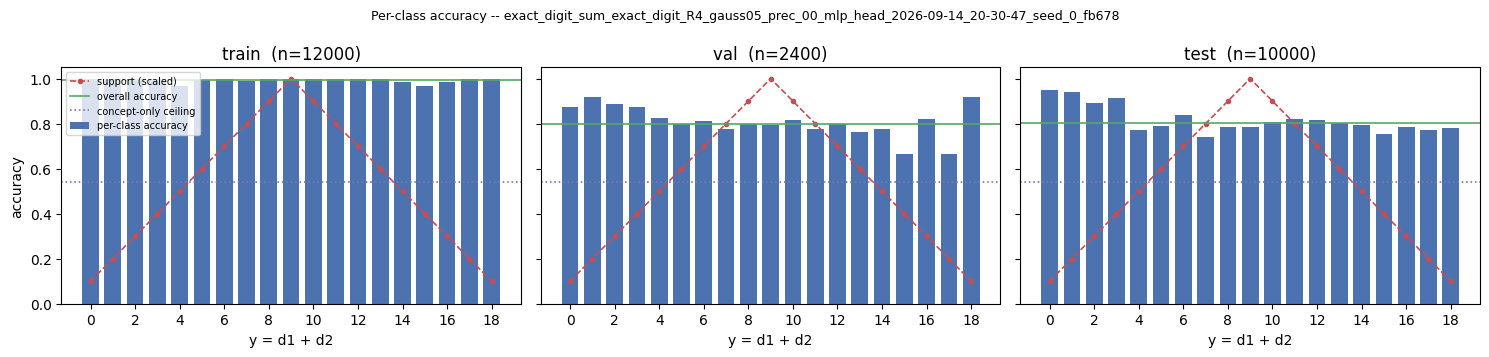

In [5]:
# Per-class accuracy against support, all splits. Classes the model never predicts
# (n_pred = 0 above) show as an accuracy of exactly zero -- a collapsed class, not a
# hard one, and the distinction matters when reading the confusion matrix next.
fig, axes = plt.subplots(1, len(SPLITS), figsize=(5.0 * len(SPLITS), 3.6), sharey=True)

for ax, split in zip(np.atleast_1d(axes), SPLITS):
    d = DATA[split]
    rows = per_class_table(d)
    classes = [r["class"] for r in rows]
    acc = [r["accuracy"] for r in rows]
    support = np.array([r["support"] for r in rows], float)
    ceiling, _ = concept_only_ceiling(d["c_true"], d["y_true"])

    ax.bar(classes, acc, color="#4C72B0", width=0.75,
           label="per-class accuracy")
    ax.plot(classes, support / support.max(), color="#C44E52", lw=1.2, ls="--",
            marker="o", ms=3, label="support (scaled)")
    ax.axhline((d["y_hat"] == d["y_true"]).mean(), color="#55A868", lw=1.2,
               label="overall accuracy")
    ax.axhline(ceiling, color="#8172B2", lw=1.2, ls=":", label="concept-only ceiling")
    ax.set_title(f"{split}  (n={len(d['y_true'])})")
    ax.set_xlabel("y = d1 + d2")
    ax.set_xticks(range(0, NUM_CLASSES, 2))
    ax.set_ylim(0, 1.05)

np.atleast_1d(axes)[0].set_ylabel("accuracy")
np.atleast_1d(axes)[0].legend(fontsize=7, loc="upper left")
fig.suptitle(f"Per-class accuracy -- {RUN.name}", fontsize=9)
fig.tight_layout()
plt.show()

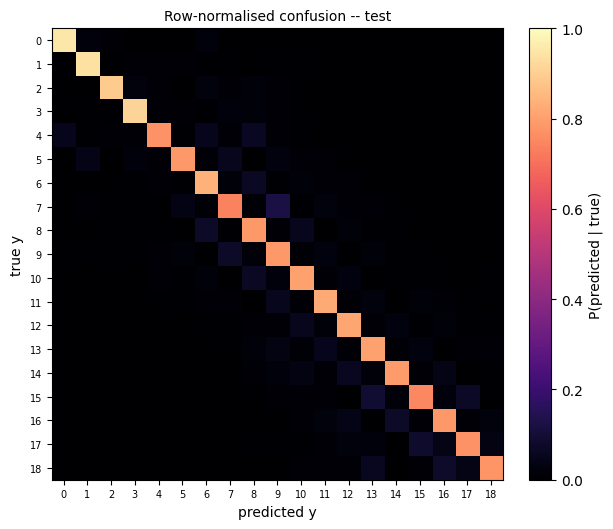

In [6]:
# Row-normalised confusion matrix: where does the mass of each true sum actually go?
# Rows are true y, columns predicted y, so a bright off-diagonal band at +-k means the
# model is systematically off by k -- the signature of resolving a digit to the wrong
# member of an ambiguous pair.
d = DATA[SPLIT]
confusion = np.zeros((NUM_CLASSES, NUM_CLASSES))
np.add.at(confusion, (d["y_true"], d["y_hat"]), 1)
confusion_norm = confusion / np.maximum(confusion.sum(1, keepdims=True), 1)

fig, ax = plt.subplots(figsize=(6.2, 5.4))
im = ax.imshow(confusion_norm, cmap="magma", vmin=0, vmax=1)
ax.set_xlabel("predicted y")
ax.set_ylabel("true y")
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.tick_params(labelsize=7)
ax.set_title(f"Row-normalised confusion -- {SPLIT}", fontsize=10)
fig.colorbar(im, ax=ax, fraction=0.046, label="P(predicted | true)")
fig.tight_layout()
plt.show()

### Where the errors live: the ambiguous digit pairs

The per-class picture is driven by the designed concept collisions. Digits `{0,4}`,
`{5,7}` and `{6,8}` are pairwise indistinguishable from the concept bits, so the exact
sum is only identifiable when the residual resolves them. Splitting accuracy by the
oracle digits shows directly whether it does.

concept-code collisions: [[0, 4], [5, 7], [6, 8]]
ambiguous digits: [0, 4, 5, 6, 7, 8]


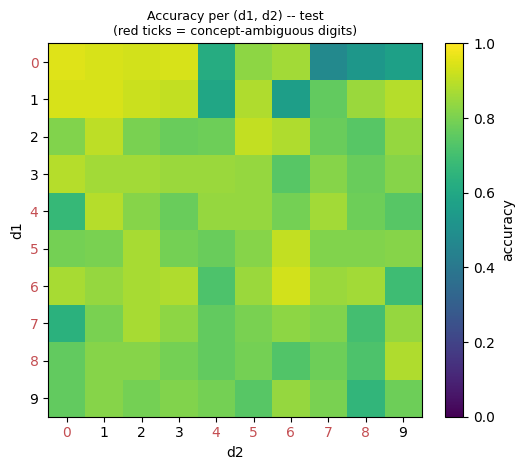


ambiguous digits in sample        n  accuracy
0                              1600     0.848
1                              4800     0.808
2                              3600     0.781


In [7]:
PRIMES = {2, 3, 5, 7}


def digit_code(digit):
    return (int(digit >= THRESHOLD), int(digit in PRIMES), int(digit % 2 == 0))


# Digits sharing a concept code are the ones the bottleneck cannot separate.
collisions = {}
for digit in range(10):
    collisions.setdefault(digit_code(digit), []).append(digit)
AMBIGUOUS = {d for group in collisions.values() if len(group) > 1 for d in group}
print("concept-code collisions:",
      [group for group in collisions.values() if len(group) > 1])
print("ambiguous digits:", sorted(AMBIGUOUS))

d = DATA[SPLIT]
correct = d["y_hat"] == d["y_true"]
d1, d2 = d["digits"][:, 0], d["digits"][:, 1]

# Accuracy per ordered digit pair.
pair_acc = np.full((10, 10), np.nan)
for a in range(10):
    for b in range(10):
        cell = (d1 == a) & (d2 == b)
        if cell.any():
            pair_acc[a, b] = correct[cell].mean()

fig, ax = plt.subplots(figsize=(5.6, 4.8))
im = ax.imshow(pair_acc, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("d2"); ax.set_ylabel("d1")
for tick in ax.get_xticklabels():
    if int(tick.get_text()) in AMBIGUOUS: tick.set_color("#C44E52")
for tick in ax.get_yticklabels():
    if int(tick.get_text()) in AMBIGUOUS: tick.set_color("#C44E52")
ax.set_title(f"Accuracy per (d1, d2) -- {SPLIT}\n(red ticks = concept-ambiguous digits)",
             fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046, label="accuracy")
fig.tight_layout()
plt.show()

n_ambiguous = np.isin(d1, list(AMBIGUOUS)).astype(int) + np.isin(d2, list(AMBIGUOUS)).astype(int)
print(f"\n{'ambiguous digits in sample':<28}{'n':>7}{'accuracy':>10}")
for k in (0, 1, 2):
    cell = n_ambiguous == k
    print(f"{k:<28}{cell.sum():>7}{correct[cell].mean():>10.3f}")

In [8]:
# For each collision group, which member does the model resolve towards? A signed
# mean error that tracks the gap between the two members (e.g. -2 for {5,7}) means the
# model is reading the ambiguous digit as the other member of its pair, i.e. the
# residual is not carrying the identity.
print(f"{'digit':>6}{'n(d1)':>8}{'acc':>8}{'mean(yhat - y)':>16}")
for group in [g for g in collisions.values() if len(g) > 1]:
    for digit in group:
        cell = d1 == digit
        print(f"{digit:>6}{cell.sum():>8}{correct[cell].mean():>8.3f}"
              f"{np.mean(d['y_hat'][cell] - d['y_true'][cell]):>+16.2f}")
    print()

 digit   n(d1)     acc  mean(yhat - y)
     0    1000   0.764           +0.16
     4    1000   0.800           +0.15

     5    1000   0.819           +0.09
     7    1000   0.788           -0.21

     6    1000   0.836           -0.13
     8    1000   0.785           -0.21



## 2. Absolute correlation matrix of the amortized `Sigma(x)`

`covariance_matrices.pt` holds `Sigma = L L^T` per sample -- the validator already does
the reconstruction before saving, so the tensor **must not be squared again**.

Normalising each sample to `rho_ij = Sigma_ij / sqrt(Sigma_ii Sigma_jj)` and averaging
`|rho|` over samples gives the typical magnitude of coupling, which is what to plot:
signed entries average towards zero when the sign flips across samples, so a signed
mean can hide real structure.

**Read the diagonal of `Sigma` first.** On clean MNIST the concept posteriors sharpen
and the `Sigma` diagonal collapses, at which point every `rho` entry is a 0/0 ratio
with nothing to read off -- the caveat written into
[configs/data/mnist_add.yaml](configs/data/mnist_add.yaml). The diagnostic below is
printed before the heatmap for that reason.

In [9]:
def absolute_correlation(Sigma):
    """Mean |rho| over samples, plus the signed mean, from per-sample Sigma."""
    sd = np.sqrt(np.einsum("nii->ni", Sigma))
    rho = Sigma / (sd[:, :, None] * sd[:, None, :])
    return np.abs(rho).mean(0), rho.mean(0)


Sigma = DATA[SPLIT]["Sigma"]
abs_rho, signed_rho = absolute_correlation(Sigma)

diag = np.einsum("nii->ni", Sigma).mean(0)
print(f"mean Sigma diagonal ({SPLIT}):")
for name, value in zip(CHANNEL_NAMES, diag):
    print(f"  {name:<16}{value:>10.4f}")

off_diagonal = ~np.eye(len(CHANNEL_NAMES), dtype=bool)
cross_block = abs_rho[:NUM_CONCEPTS, NUM_CONCEPTS:]
print(f"\nmean |rho| off-diagonal      : {abs_rho[off_diagonal].mean():.5f}"
      f"   (max {abs_rho[off_diagonal].max():.5f})")
print(f"mean |rho| concept-residual  : {cross_block.mean():.5f}"
      f"   (max {cross_block.max():.5f})")
if cross_block.max() < 0.01:
    print("\n  WARNING: the concept-residual block is numerically zero. With clean images "
          "\n  Sigma(x) has collapsed and these entries carry no signal -- rerun with "
          "\n  corruption='gaussian', strength 0.5, channels 'all' before interpreting them.")

mean Sigma diagonal (test):
  D1_HIGH(>=5)        0.0001
  D1_PRIME            0.0798
  D1_EVEN             0.1638
  D2_HIGH(>=5)        0.7575
  D2_PRIME            0.1925
  D2_EVEN             0.1161
  res_0               0.5026
  res_1               3.7798
  res_2               0.3604
  res_3               2.0617

mean |rho| off-diagonal      : 0.38024   (max 0.96904)
mean |rho| concept-residual  : 0.29382   (max 0.39051)


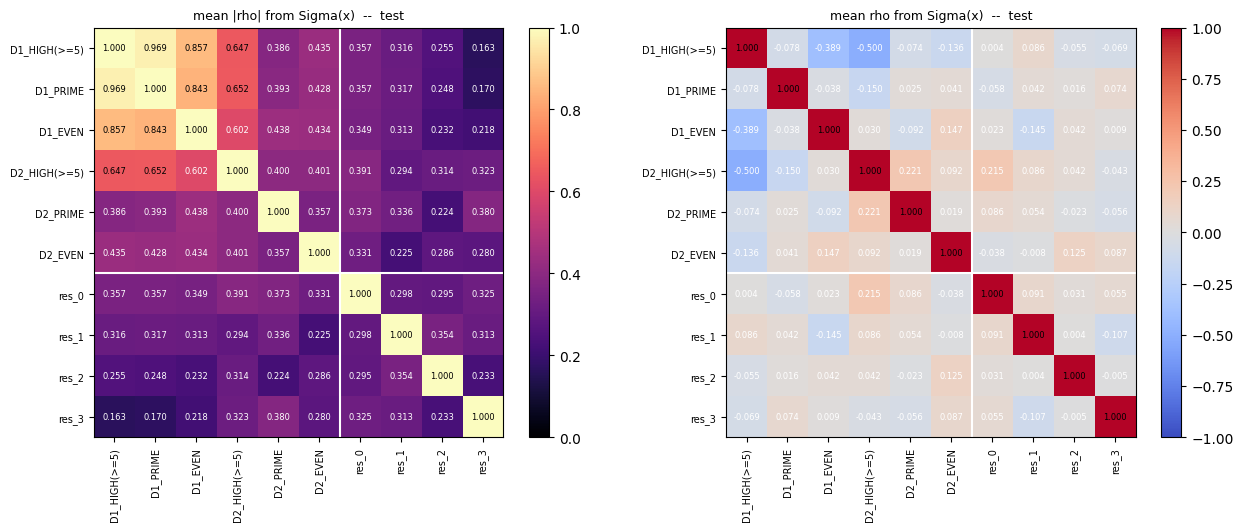

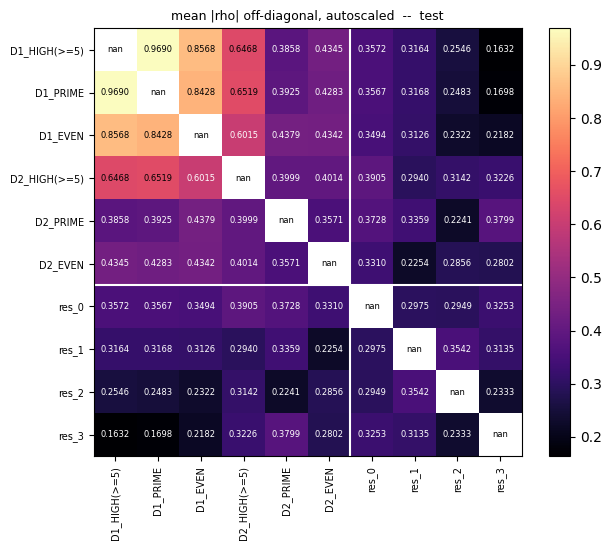

In [10]:
def plot_matrix(matrix, title, cmap="magma", vmin=None, vmax=None, fmt="{:.2f}",
                annotate=True, ax=None):
    """Labelled heatmap over the [concepts | residuals] channel, with the block split drawn."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6.6, 5.6))
    im = ax.imshow(matrix, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(CHANNEL_NAMES)), CHANNEL_NAMES, rotation=90, fontsize=7)
    ax.set_yticks(range(len(CHANNEL_NAMES)), CHANNEL_NAMES, fontsize=7)
    # The line separating the concept block from the residual block.
    for line in (ax.axvline, ax.axhline):
        line(NUM_CONCEPTS - 0.5, color="w", lw=1.5)
    if annotate:
        span = (np.nanmax(matrix) - np.nanmin(matrix)) or 1.0
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                shade = (matrix[i, j] - np.nanmin(matrix)) / span
                ax.text(j, i, fmt.format(matrix[i, j]), ha="center", va="center",
                        fontsize=6, color="w" if shade < 0.55 else "k")
    ax.set_title(title, fontsize=9)
    ax.figure.colorbar(im, ax=ax, fraction=0.046)
    return ax


fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.4))
plot_matrix(abs_rho, f"mean |rho| from Sigma(x)  --  {SPLIT}", vmin=0, vmax=1,
            fmt="{:.3f}", ax=axes[0])
plot_matrix(signed_rho, f"mean rho from Sigma(x)  --  {SPLIT}", cmap="coolwarm",
            vmin=-1, vmax=1, fmt="{:.3f}", ax=axes[1])
fig.tight_layout()
plt.show()

# The same on the off-diagonal scale, where any surviving structure is visible.
off = abs_rho.copy()
np.fill_diagonal(off, np.nan)
plot_matrix(off, f"mean |rho| off-diagonal, autoscaled  --  {SPLIT}", fmt="{:.4f}")
plt.tight_layout()
plt.show()

## 3. Correlation matrix of `c_res_mu`

`c_res_mu.pt` is the predicted Gaussian **mean** `[mu_c(x) | mu_r(x)]`, one row per
sample. Its Pearson correlation across the dataset is a different quantity from
section 2: section 2 asks how concepts and residuals co-vary *within* a sample's
posterior, this asks how their predicted means co-vary *across* inputs.

A residual column correlating strongly with a concept column here is leakage -- the
residual mean tracking information already present in the bottleneck. That is what the
OLS-cleaning step of the pipeline removes before the residual is scored against hidden
concepts.

c_res_mu.shape = (10000, 10)   split = test

channel                 mean       std
D1_HIGH(>=5)           0.692    33.742
D1_PRIME              -7.024    29.116
D1_EVEN               -3.291    29.727
D2_HIGH(>=5)           0.937    34.135
D2_PRIME              -6.758    29.520
D2_EVEN               -3.347    29.515
res_0                 11.088    27.646
res_1                  8.001    22.186
res_2                 15.758    24.822
res_3                 -2.599    17.459


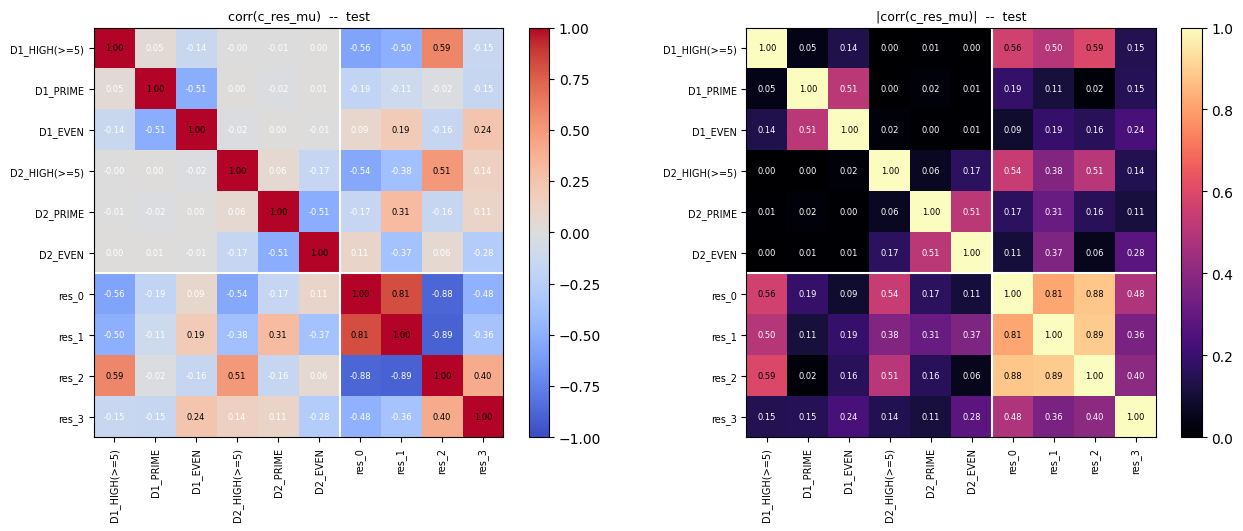

In [11]:
mu = DATA[SPLIT]["c_res_mu"]
corr_mu = np.corrcoef(mu.T)

print(f"c_res_mu.shape = {mu.shape}   split = {SPLIT}\n")
print(f"{'channel':<18}{'mean':>10}{'std':>10}")
for name, column in zip(CHANNEL_NAMES, mu.T):
    print(f"{name:<18}{column.mean():>10.3f}{column.std():>10.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.4))
plot_matrix(corr_mu, f"corr(c_res_mu)  --  {SPLIT}", cmap="coolwarm", vmin=-1, vmax=1,
            ax=axes[0])
plot_matrix(np.abs(corr_mu), f"|corr(c_res_mu)|  --  {SPLIT}", vmin=0, vmax=1,
            ax=axes[1])
fig.tight_layout()
plt.show()

In [12]:
# Leakage summary: how much of each residual mean is linearly explained by the
# concept means? R^2 of res_j regressed on [1, mu_c] -- the same quantity the cleaning
# step removes. A high R^2 means the raw residual column is mostly restating the
# bottleneck, and any AUROC measured on it before cleaning is not evidence of a
# recovered hidden concept.
c_mu, res_mu = mu[:, :NUM_CONCEPTS], mu[:, NUM_CONCEPTS:]
design = np.concatenate([np.ones((len(mu), 1)), c_mu], axis=1)
beta, *_ = np.linalg.lstsq(design, res_mu, rcond=None)
res_clean = res_mu - design @ beta

print(f"{'residual':<10}{'R^2 on c_mu':>14}{'max |corr| w/ concept':>24}")
for j, name in enumerate(RESIDUAL_NAMES):
    r2 = 1 - res_clean[:, j].var() / res_mu[:, j].var()
    concept_corr = np.abs(corr_mu[NUM_CONCEPTS + j, :NUM_CONCEPTS])
    strongest = CONCEPT_NAMES[concept_corr.argmax()]
    print(f"{name:<10}{r2:>14.3f}{concept_corr.max():>18.3f}  ({strongest})")

print(f"\nresidual-residual |corr| (off-diagonal): "
      f"mean {np.abs(corr_mu[NUM_CONCEPTS:, NUM_CONCEPTS:])[~np.eye(NUM_RESIDUALS, dtype=bool)].mean():.3f}")

residual     R^2 on c_mu   max |corr| w/ concept
res_0              0.670             0.563  (D1_HIGH(>=5))
res_1              0.609             0.499  (D1_HIGH(>=5))
res_2              0.661             0.592  (D1_HIGH(>=5))
res_3              0.158             0.277  (D2_EVEN)

residual-residual |corr| (off-diagonal): mean 0.638


c_res_mu_prob.shape = (10000, 10)   split = test


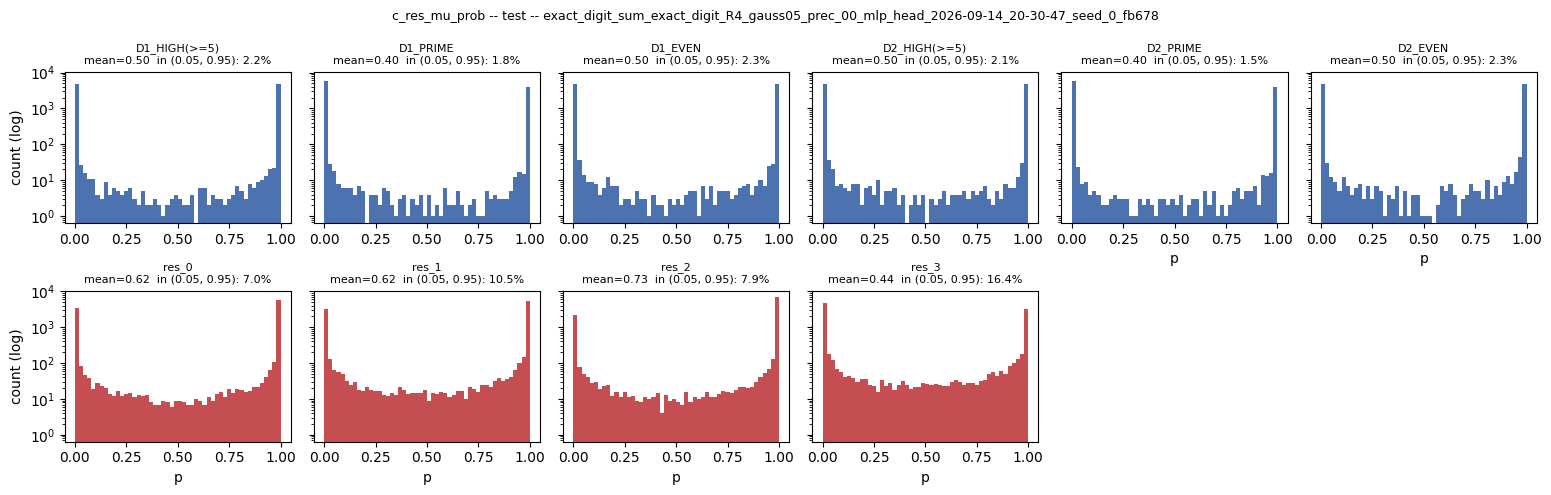

In [13]:
# Distribution of the predicted probabilities sigma(mu) per channel, [concepts | residuals].
#
# concepts_residuals_pred_probs_mean.pt is the per-sample probability of each channel. The
# probabilities pile up at 0 and 1, so counts are on a log scale -- on a linear axis the two
# end bins swamp everything in between. Top row concepts, bottom row residuals (red).
c_res_mu_prob = torch.load(RUN / SPLIT / "concepts_residuals_pred_probs_mean.pt",
                           map_location="cpu").numpy()
print(f"c_res_mu_prob.shape = {c_res_mu_prob.shape}   split = {SPLIT}")

bins = np.linspace(0, 1, 51)
n_cols = max(NUM_CONCEPTS, NUM_RESIDUALS)
fig, axes = plt.subplots(2, n_cols, figsize=(2.6 * n_cols, 5.0), sharex=True, sharey=True,
                         squeeze=False)
for row, (names, offset, color) in enumerate(
    ((CONCEPT_NAMES, 0, "#4C72B0"), (RESIDUAL_NAMES, NUM_CONCEPTS, "#C44E52"))
):
    for j in range(n_cols):
        ax = axes[row, j]
        if j >= len(names):
            ax.axis("off")
            continue
        p = c_res_mu_prob[:, offset + j]
        ax.hist(p, bins=bins, color=color)
        ax.set_yscale("log")
        ax.set_title(f"{names[j]}\nmean={p.mean():.2f}  in (0.05, 0.95): "
                     f"{((p > 0.05) & (p < 0.95)).mean():.1%}", fontsize=8)
        if row == 1 or j >= len(RESIDUAL_NAMES):
            ax.set_xlabel("p")
        ax.tick_params(labelbottom=True)
axes[0, 0].set_ylabel("count (log)")
axes[1, 0].set_ylabel("count (log)")
fig.suptitle(f"c_res_mu_prob -- {SPLIT} -- {RUN.name}", fontsize=9)
fig.tight_layout()
plt.show()

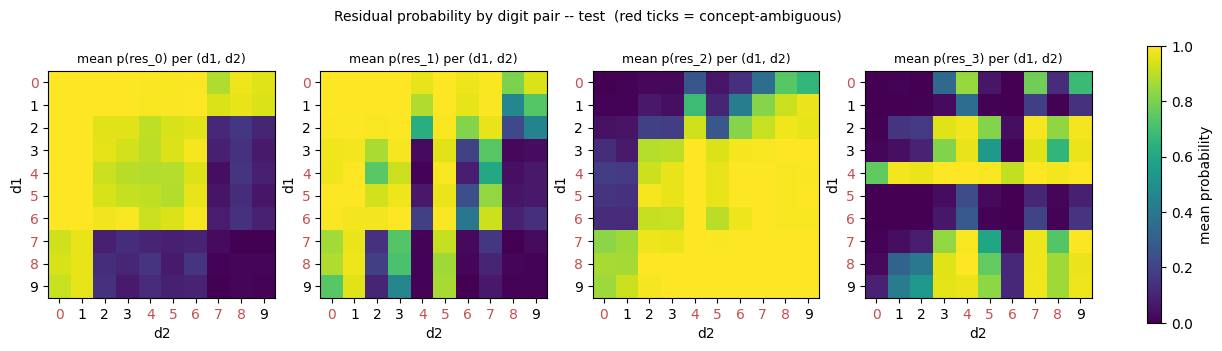

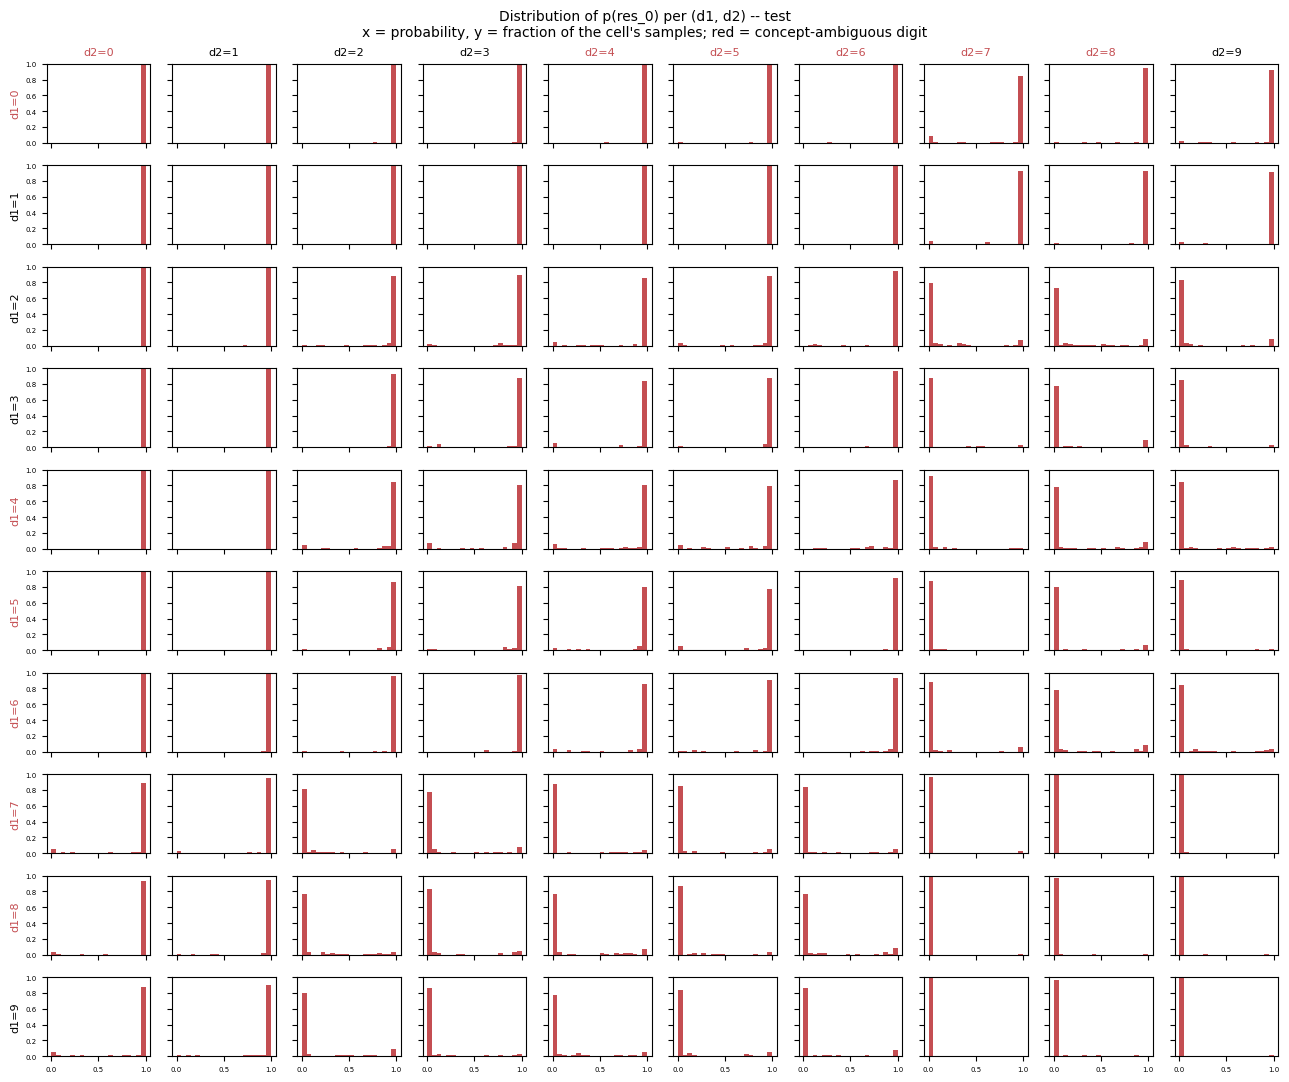

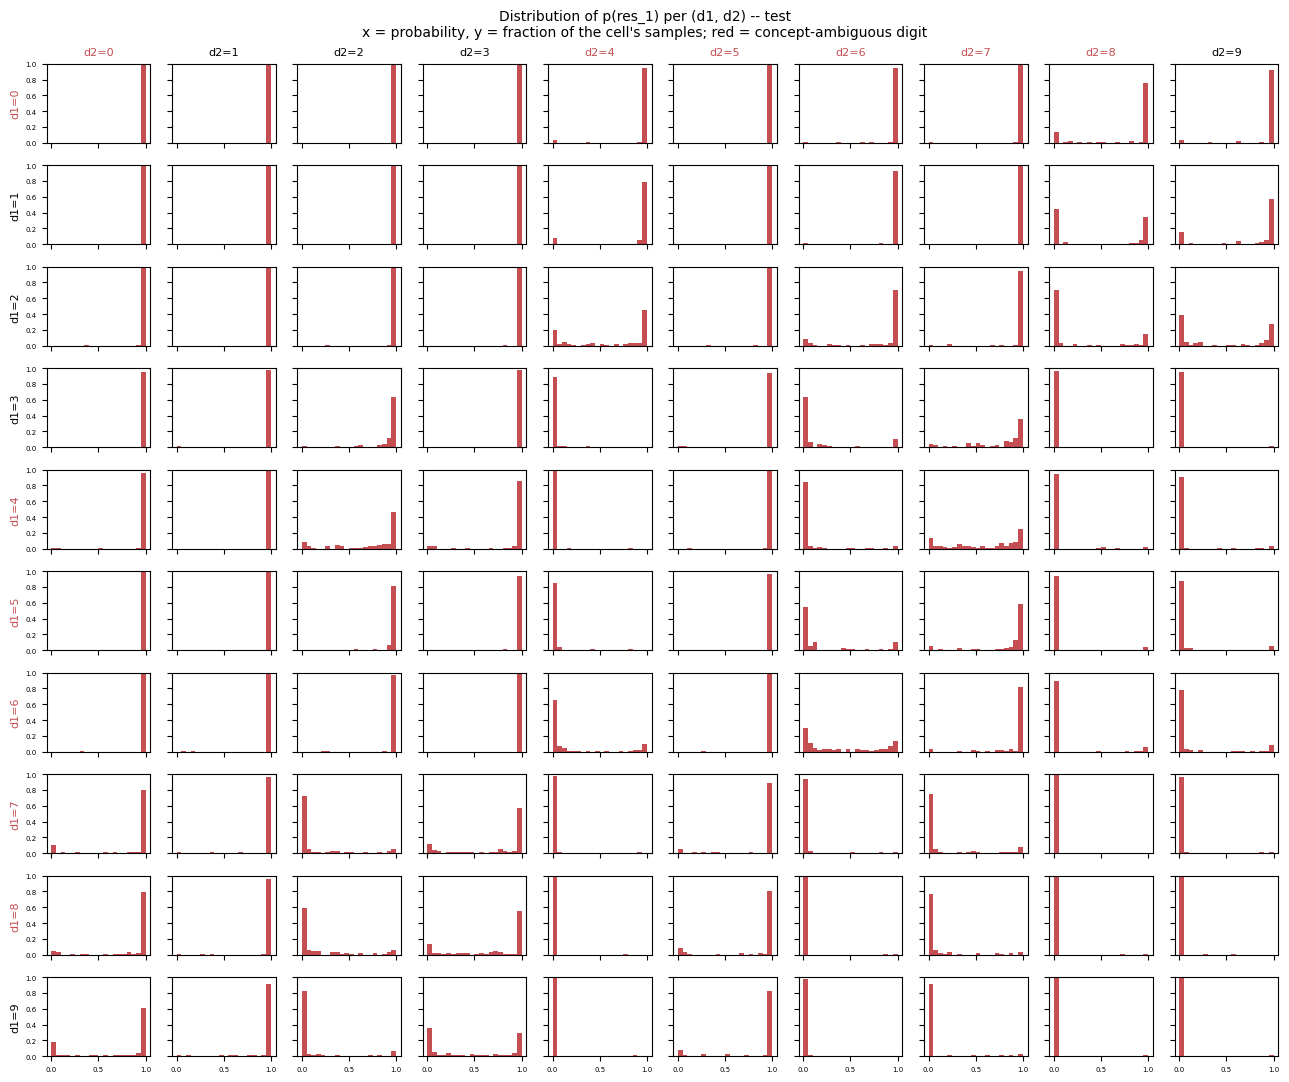

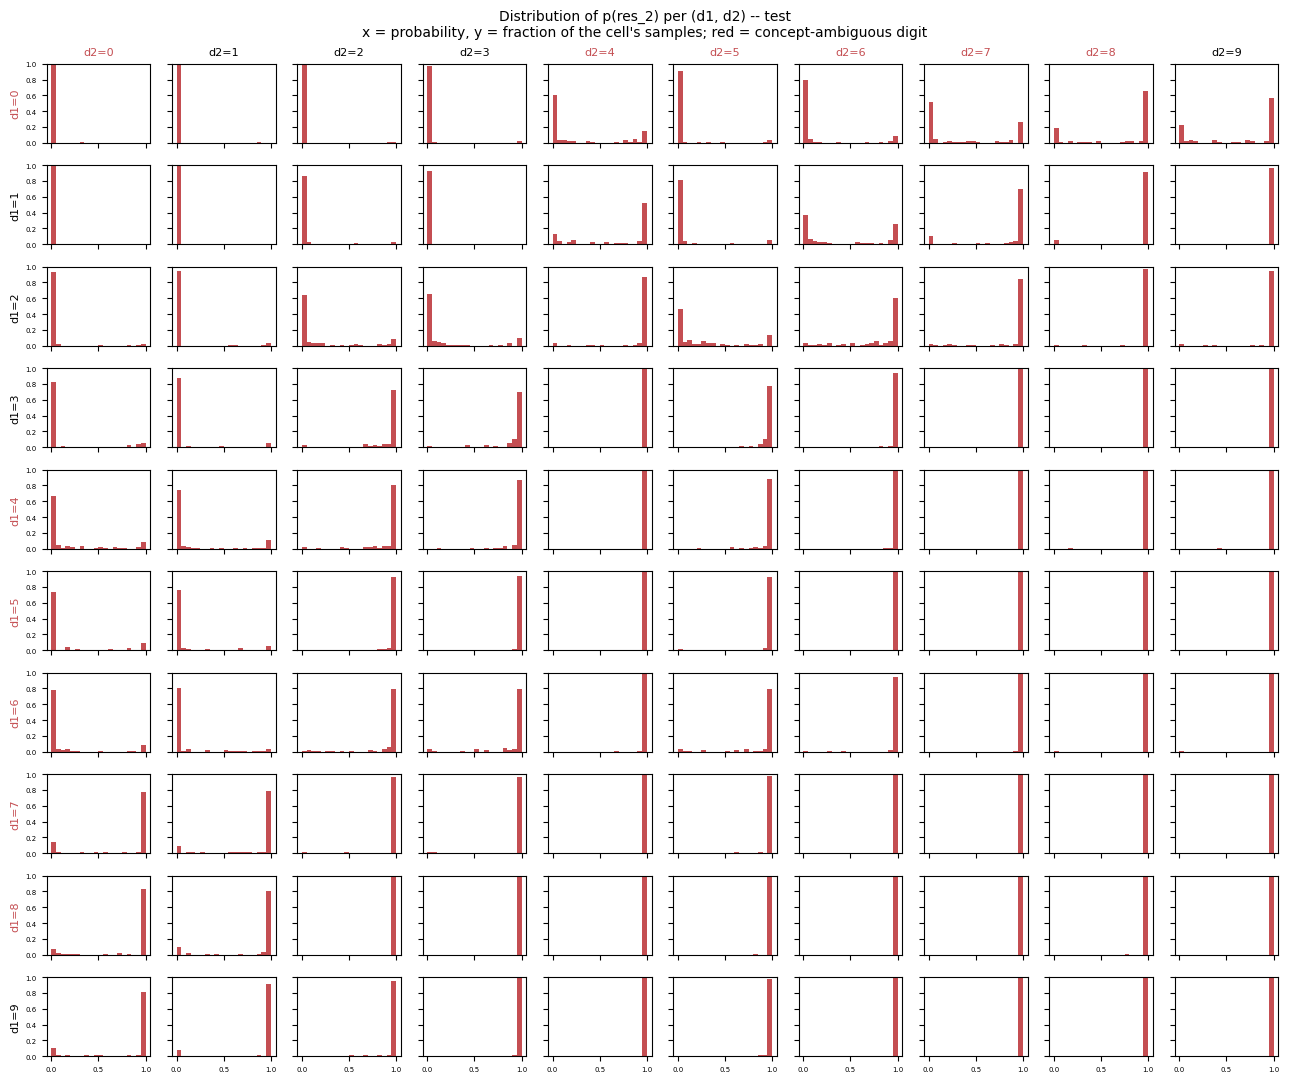

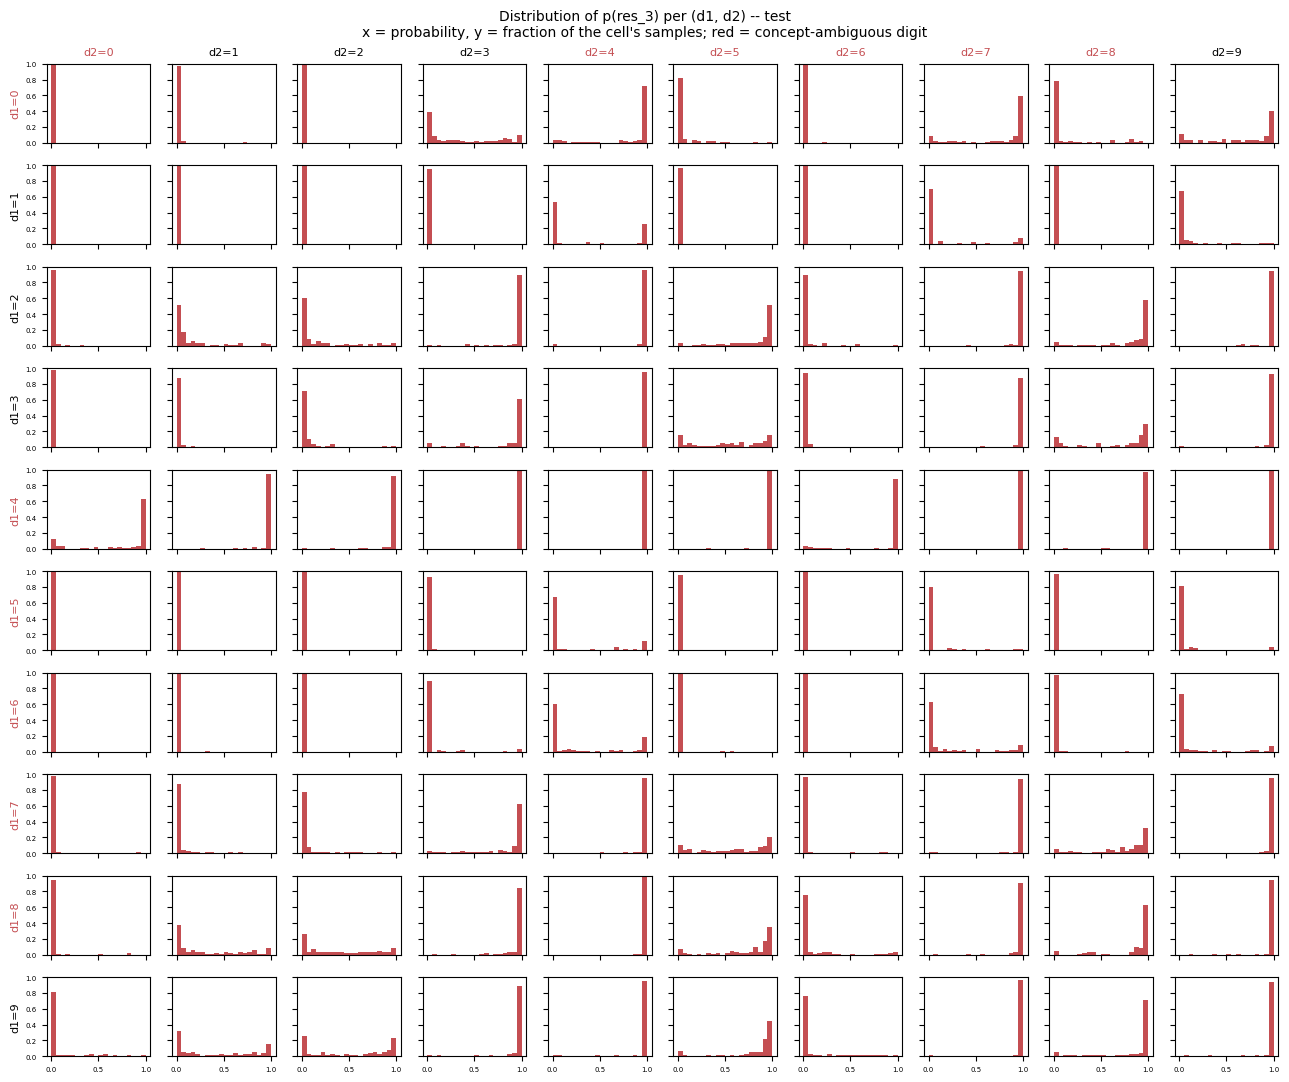

In [14]:
# Residual probabilities per ordered digit pair (d1, d2), using the oracle digits.
#
# Each residual is close to binary (previous cell), so the mean probability over one
# (d1, d2) cell is roughly the fraction of that cell's samples where the residual is on.
# A residual carrying hidden digit identity should differ between digits that share a
# concept code -- rows/columns {0,4}, {5,7}, {6,8}, red ticks as in section 1.
# Reuses c_res_mu_prob (previous cell) and AMBIGUOUS (section 1).
digits = DATA[SPLIT]["digits"]
assert len(digits) == len(c_res_mu_prob), "digits and probabilities are misaligned"
res_prob = c_res_mu_prob[:, NUM_CONCEPTS:]
d1, d2 = digits[:, 0], digits[:, 1]

pair_mean = np.full((NUM_RESIDUALS, 10, 10), np.nan)
for a in range(10):
    for b in range(10):
        cell = (d1 == a) & (d2 == b)
        if cell.any():
            pair_mean[:, a, b] = res_prob[cell].mean(0)


def mark_ambiguous(ax):
    for tick in (*ax.get_xticklabels(), *ax.get_yticklabels()):
        if tick.get_text() and int(tick.get_text()) in AMBIGUOUS:
            tick.set_color("#C44E52")


# (a) Mean probability per pair, one heatmap per residual.
fig, axes = plt.subplots(1, NUM_RESIDUALS, figsize=(3.6 * NUM_RESIDUALS, 3.6), squeeze=False)
for k, ax in enumerate(axes[0]):
    im = ax.imshow(pair_mean[k], cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    ax.set_xlabel("d2"); ax.set_ylabel("d1")
    mark_ambiguous(ax)
    ax.set_title(f"mean p({RESIDUAL_NAMES[k]}) per (d1, d2)", fontsize=9)
fig.colorbar(im, ax=axes, fraction=0.015, label="mean probability")
fig.suptitle(f"Residual probability by digit pair -- {SPLIT}  (red ticks = concept-ambiguous)",
             fontsize=10)
plt.show()

# (b) The full distribution per pair: a 10x10 grid of histograms per residual.
# Rows are d1, columns d2; y is the fraction of the cell's samples (about 100 per cell).
bins = np.linspace(0, 1, 21)
for k in range(NUM_RESIDUALS):
    fig, axes = plt.subplots(10, 10, figsize=(13, 11), sharex=True, sharey=True)
    for a in range(10):
        for b in range(10):
            ax = axes[a, b]
            p = res_prob[(d1 == a) & (d2 == b), k]
            if len(p):
                ax.hist(p, bins=bins, weights=np.full(len(p), 1 / len(p)), color="#C44E52")
            ax.set_ylim(0, 1)
            ax.tick_params(labelsize=5)
            if a == 0:
                ax.set_title(f"d2={b}", fontsize=8,
                             color="#C44E52" if b in AMBIGUOUS else "k")
            if b == 0:
                ax.set_ylabel(f"d1={a}", fontsize=8,
                              color="#C44E52" if a in AMBIGUOUS else "k")
    fig.suptitle(f"Distribution of p({RESIDUAL_NAMES[k]}) per (d1, d2) -- {SPLIT}\n"
                 f"x = probability, y = fraction of the cell's samples; red = concept-ambiguous digit",
                 fontsize=10)
    fig.tight_layout()
    plt.show()

## Splits side by side

All three matrices are recomputed per split as a stability check -- structure that only
shows up on one split is a property of that split, not of the model.

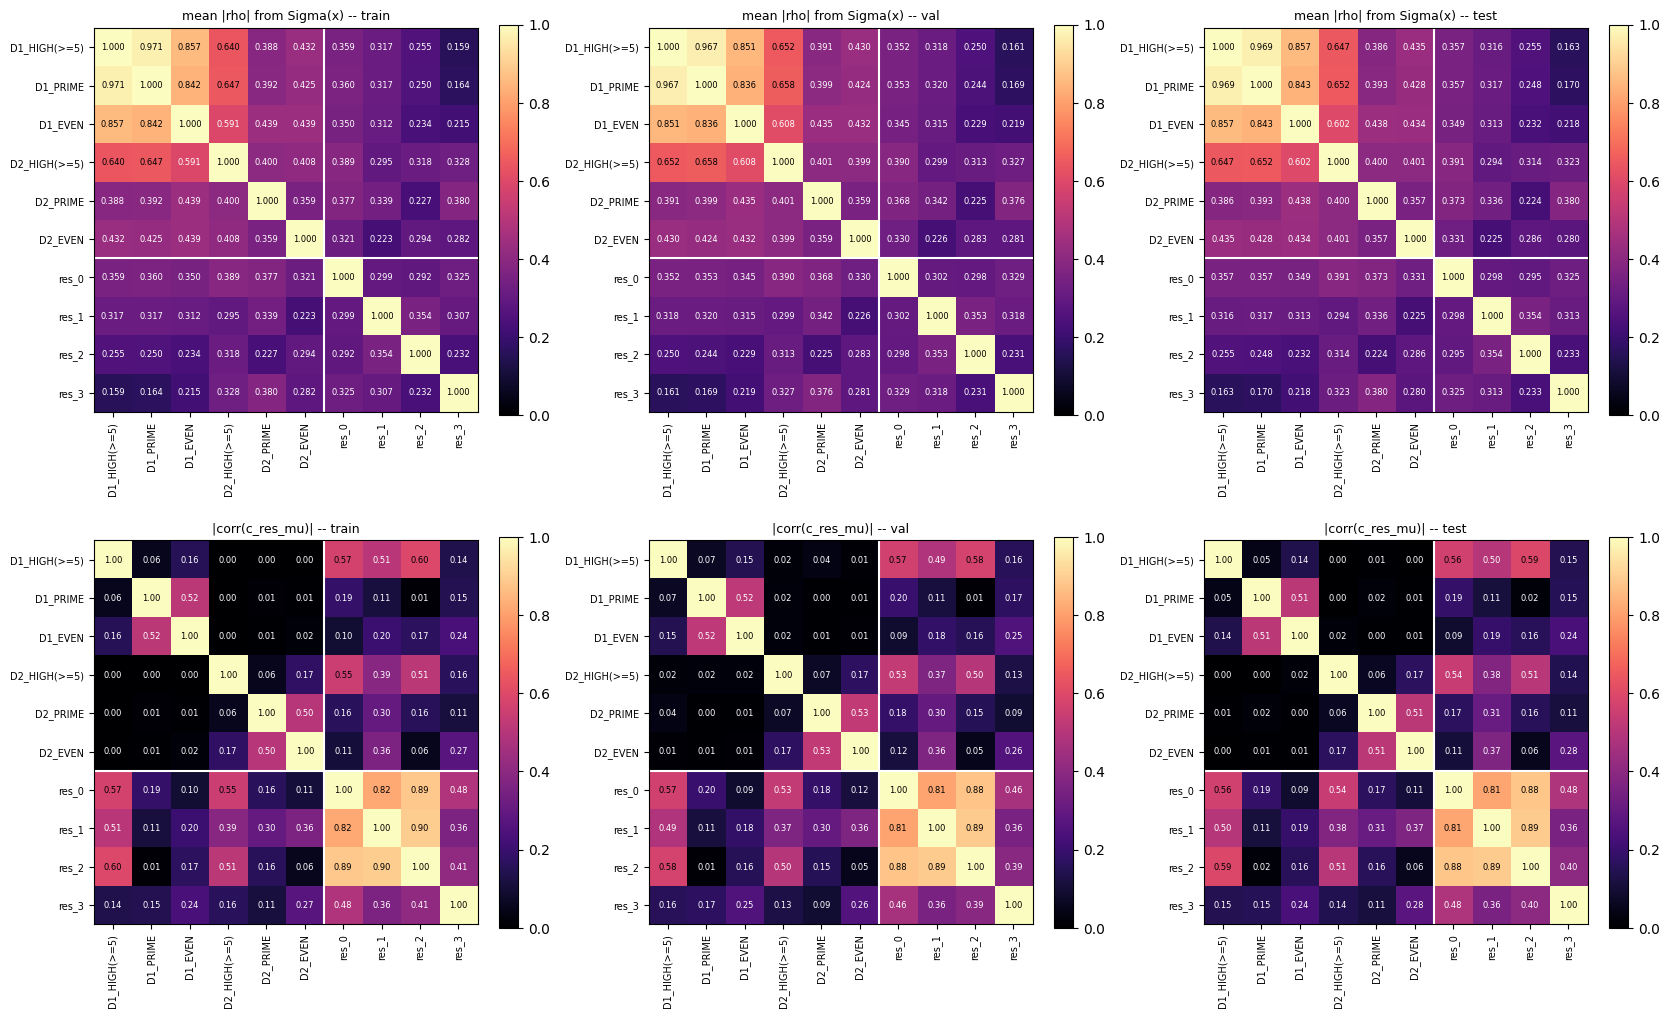

In [15]:
fig, axes = plt.subplots(2, len(SPLITS), figsize=(5.6 * len(SPLITS), 10.4))
for column, split in enumerate(SPLITS):
    abs_rho_split, _ = absolute_correlation(DATA[split]["Sigma"])
    plot_matrix(abs_rho_split, f"mean |rho| from Sigma(x) -- {split}", vmin=0, vmax=1,
                fmt="{:.3f}", ax=axes[0, column])
    plot_matrix(np.abs(np.corrcoef(DATA[split]["c_res_mu"].T)),
                f"|corr(c_res_mu)| -- {split}", vmin=0, vmax=1, ax=axes[1, column])
fig.tight_layout()
plt.show()

## 4. Digit attribution per residual

The claim under test is **"residual k belongs to digit 1 (or digit 2)"**. The `C-R` columns of the
per-class and per-pair tables cannot test it: they average all residuals against all concepts, so a
residual attached to digit 1 and one attached to digit 2 contribute the same amount. Those columns
measure *how much* coupling exists, not *where it goes*.

Per residual `k` and digit group `G` (`D1` = `{D1_HIGH, D1_PRIME, D1_EVEN}`, likewise `D2`, and `D3`,
`D4` once they exist):

    A_k(G)     = coupling of res_k to digit group G
    share_k(G) = A_k(G) / sum_G' A_k(G')          # 1/#groups (0.5 here) = no attribution

Two readouts of `A`, both over the **whole** split. Conditioning on `y` welds the digits together
and destroys the asymmetry being measured.

- **Σ (covariance readout).** Mean over samples of the per-sample `|rho(res_k, c)|` from `Sigma(x)`,
  averaged over the concepts `c` of `G`. `D1_HIGH` is excluded because its variance has collapsed
  (median 0; see section 2). Samples where either variance is `<= VAR_EPS` are masked entry by entry,
  because there `rho` is a ratio of rounding errors. `D1_PRIME` is also close to collapse (median
  variance about 0.01), and the kept-fraction line reports this.
- **μ (cleaned-mean readout).** The literal version, Pearson `corr(OLS-cleaned res_k, c_mu)`, is
  **identically zero**: OLS residuals are orthogonal to their regressors (max |corr| = 1e-15 on this
  run). The μ readout therefore scores the cleaned residual against the variable it is supposed to
  carry, the hidden digit identity:

      A_k(Dj) = eta^2(res_clean_k | d_j) - eta^2(res_clean_k | code(d_j))

  This is the fraction of res_k's cleaned variance that separates digits **sharing a concept code**
  (`{0,4}`, `{5,7}`, `{6,8}`). The code is held fixed, so it cannot be concept copy. It uses the
  oracle digits, as analysis metadata only.

A residual that belongs to digit 2 has `share(D1)` well below 0.5 on **both** readouts, and stays
there across seeds. `ATTR_RUNS` takes further seeds and the null run, where the target is fully
determined by the concepts. The spread of the null run's shares is the error bar.

Guardrail: the μ readout says what hidden identity is *recoverable* from `res_k`, not that `res_k`
*is* that digit.

seed 0: exact_digit_sum_exact_digit_R4_gauss05_prec_00_mlp_head_2026-09-14_20-30-47_seed_0_fb678
split = test   n = 10000   excluded from Sigma: ['D1_HIGH']
Sigma samples kept per concept: D1_HIGH(>=5)=0.115  D1_PRIME=0.943  D1_EVEN=0.999  D2_HIGH(>=5)=1.000  D2_PRIME=1.000  D2_EVEN=1.000

        | Sigma: mean |rho|                      | mu: hidden-identity eta^2 (cleaned)
        |      A D1     A D2  share D1  share D2 |      A D1     A D2  share D1  share D2
res_0   |     0.353    0.365      0.49      0.51 |     0.288    0.293      0.50      0.50
res_1   |     0.315    0.285      0.52      0.48 |     0.254    0.338      0.43      0.57
res_2   |     0.240    0.275      0.47      0.53 |     0.257    0.288      0.47      0.53
res_3   |     0.194    0.328      0.37      0.63 |     0.422    0.182      0.70      0.30



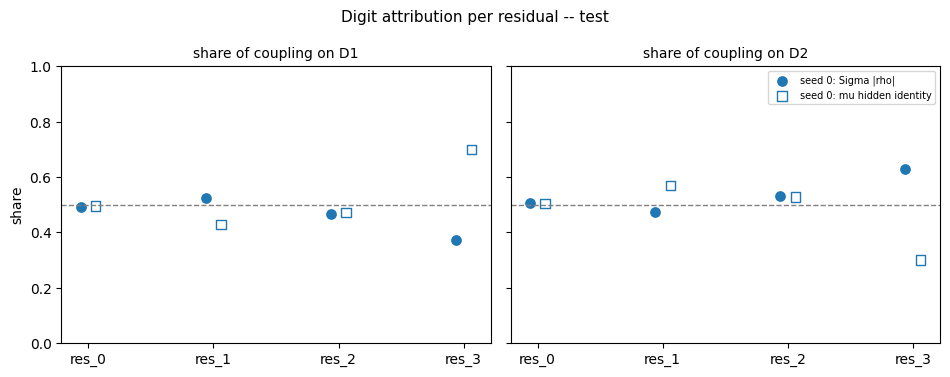

In [16]:
import warnings

# Digit attribution per residual. See the markdown above for the two readouts.
# Reuses load_split (cell 2) and digit_code (section 1).
ATTR_SPLIT = "test"                 # the whole split, never conditioned on y
EXCLUDE_CONCEPTS = ("D1_HIGH",)     # collapsed Sigma diagonal (section 2); set to () once fixed
VAR_EPS = 1e-4                      # Sigma readout: mask rho wherever either variance is <= this
# Add further seeds and the null run (target fully determined by the concepts) here. The spread of
# the null run's shares is the error bar for every other run.
ATTR_RUNS = {"seed 0": RUN}

DIGIT_GROUPS = sorted({name.split("_")[0] for name in CONCEPT_NAMES})      # ["D1", "D2"]
# Concept code of each digit as one integer, so eta^2 can group by it.
CODE_OF_DIGIT = np.array([int("".join(map(str, digit_code(v))), 2) for v in range(10)])


def eta_squared(x, groups):
    """Fraction of var(x) explained by the group means of `groups`."""
    _, inverse = np.unique(groups, return_inverse=True)
    counts = np.bincount(inverse)
    means = np.bincount(inverse, weights=x) / counts
    return (counts * (means - x.mean()) ** 2).sum() / ((x - x.mean()) ** 2).sum()


def sigma_coupling(Sigma, num_concepts):
    """[R, C] mean per-sample |rho(res_k, c)|, masking near-zero variances, plus the kept fraction."""
    var = np.einsum("nii->ni", Sigma).astype(np.float64)
    sd = np.sqrt(np.clip(var, 0, None))
    C = num_concepts
    valid = (var[:, C:, None] > VAR_EPS) & (var[:, None, :C] > VAR_EPS)
    with np.errstate(invalid="ignore", divide="ignore"):
        rho = np.abs(Sigma[:, C:, :C] / (sd[:, C:, None] * sd[:, None, :C]))
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)     # all-masked entries -> NaN
        return np.nanmean(np.where(valid, rho, np.nan), 0), valid.mean(0)


def attribution(run):
    """A_k(G) for both readouts on ATTR_SPLIT of `run`: {"sigma": [R, G], "mu": [R, G], ...}."""
    config = ast.literal_eval((run / "log.txt").read_text().splitlines()[0])
    assert config["data"]["num_concepts"] == NUM_CONCEPTS, f"{run.name}: different concept layout"
    d = load_split(ATTR_SPLIT, run)
    C = NUM_CONCEPTS
    mu_c, mu_r = d["c_res_mu"][:, :C], d["c_res_mu"][:, C:]
    R = mu_r.shape[1]

    rho, kept = sigma_coupling(d["Sigma"], C)
    sigma_A = np.full((R, len(DIGIT_GROUPS)), np.nan)
    for g, group in enumerate(DIGIT_GROUPS):
        columns = [c for c, name in enumerate(CONCEPT_NAMES)
                   if name.startswith(group + "_") and not name.startswith(EXCLUDE_CONCEPTS)]
        sigma_A[:, g] = rho[:, columns].mean(1)

    # OLS-clean the residual means on [1, mu_c], then score the cleaned columns against the hidden
    # identity of each digit: variance between digits that share a concept code.
    design = np.column_stack([np.ones(len(mu_c)), mu_c])
    res_clean = mu_r - design @ np.linalg.lstsq(design, mu_r, rcond=None)[0]
    mu_A = np.full((R, len(DIGIT_GROUPS)), np.nan)
    for g, group in enumerate(DIGIT_GROUPS):
        digit = d["digits"][:, int(group[1:]) - 1]
        for k in range(R):
            mu_A[k, g] = (eta_squared(res_clean[:, k], digit)
                          - eta_squared(res_clean[:, k], CODE_OF_DIGIT[digit]))

    return {"sigma": sigma_A, "mu": mu_A, "kept": kept, "n": len(mu_c)}


def share(A):
    return A / A.sum(1, keepdims=True)


ATTR = {label: attribution(run) for label, run in ATTR_RUNS.items()}

for label, a in ATTR.items():
    R = a["sigma"].shape[0]
    print(f"{label}: {ATTR_RUNS[label].name}\nsplit = {ATTR_SPLIT}   n = {a['n']}   "
          f"excluded from Sigma: {list(EXCLUDE_CONCEPTS)}")
    # Worst case over residuals: the share of samples whose rho entry survived the VAR_EPS mask.
    print("Sigma samples kept per concept: " + "  ".join(
        f"{name}={frac:.3f}" for name, frac in zip(CONCEPT_NAMES, a["kept"].min(0))))

    block = "".join(f"{'A ' + g:>9}" for g in DIGIT_GROUPS) + "".join(f"{'share ' + g:>10}" for g in DIGIT_GROUPS)
    print(f"\n{'':<8}| {'Sigma: mean |rho|':<{len(block)}} | mu: hidden-identity eta^2 (cleaned)")
    print(f"{'':<8}| {block} | {block}")
    for k in range(R):
        cells = lambda A: ("".join(f"{v:>9.3f}" for v in A[k])
                           + "".join(f"{v:>10.2f}" for v in share(A)[k]))
        print(f"{'res_' + str(k):<8}| {cells(a['sigma'])} | {cells(a['mu'])}")
    print()

# One panel per digit group: each residual's share on that group, both readouts, every run.
# Filled circles = Sigma, open squares = mu; dashed line = no attribution.
fig, axes = plt.subplots(1, len(DIGIT_GROUPS), figsize=(4.8 * len(DIGIT_GROUPS), 3.8),
                         sharey=True, squeeze=False)
n_series = 2 * len(ATTR)
for g, (ax, group) in enumerate(zip(axes[0], DIGIT_GROUPS)):
    for i, (label, a) in enumerate(ATTR.items()):
        R = a["sigma"].shape[0]
        for r, (readout, marker) in enumerate((("sigma", "o"), ("mu", "s"))):
            offset = (2 * i + r - (n_series - 1) / 2) * 0.12
            ax.scatter(np.arange(R) + offset, share(a[readout])[:, g], marker=marker, s=45,
                       edgecolors=f"C{i}", facecolors=f"C{i}" if readout == "sigma" else "none",
                       label=f"{label}: {'Sigma |rho|' if readout == 'sigma' else 'mu hidden identity'}")
    ax.axhline(1 / len(DIGIT_GROUPS), color="0.5", ls="--", lw=1)
    ax.set_xticks(range(R), [f"res_{k}" for k in range(R)])
    ax.set_ylim(0, 1)
    ax.set_title(f"share of coupling on {group}", fontsize=10)
axes[0, 0].set_ylabel("share")
axes[0, -1].legend(fontsize=7, loc="upper right")
fig.suptitle(f"Digit attribution per residual -- {ATTR_SPLIT}", fontsize=11)
fig.tight_layout()
plt.show()

## 4c. Intervening on residuals, the SCBM way: which concepts move?

Section 4b is **not** an SCBM intervention: it thresholds the channel to bits and swaps residual
bits at the head input, so the Gaussian never enters. This section uses the intervention the
codebase runs everywhere else, just aimed the other way round.

**How interventions normally work** (`SCBM_Strategy.compute_intervention` in
[utils/intervention.py](utils/intervention.py), called by `intervene_scbm_residual_optimized`):

1. A mask picks the intervened dimensions `I`. Their logits are set to a target value `eta*_I`
   chosen by the strategy. This section uses **`emp_perc`**: the 5th percentile of that dimension's
   predicted probability on the training set for "off", the 95th for "on".
2. The rest `J` is conditioned on that, in the predicted per-sample Gaussian:

       mu_J|I    = mu_J + Sigma_JI Sigma_II^-1 (eta*_I - mu_I)
       Sigma_J|I = Sigma_JJ - Sigma_JI Sigma_II^-1 Sigma_IJ

3. Monte Carlo samples from the conditional give the new probabilities for `J`.

Normally `I` are concepts and the residuals are updated. Here `I` is a **single residual** and `J`
holds the concepts, so the readout is how much each concept probability moves:
`dp = p(concept | residual intervened) - p(concept)`. In residual mode `SCBM_Strategy` pads the mask
with zeros for the residuals, so it can't be aimed at them. The cell therefore builds it with the
whole `[concepts | residuals]` vector declared as one bottleneck. The maths is the same code, and the
covariance goes through the same `numerical_stability_check` as in the intervention loop.

**The `emp_perc` targets.** `EmpiricalPercentileStrategy` normally gets its percentiles by running the
model over `train_loader`. The cell takes them from the saved train predictions
(`train/concepts_residuals_pred_probs_mean.pt`) instead: the same probabilities, without rerunning
the model. On this run every residual is saturated on train (5th percentile ≈ 0, 95th ≈ 1), and
`torch.logit(eps=1e-6)` clamps them, so the targets are **logit −13.82 for off and +13.82 for on**
for every residual. The printed `emp_perc residual targets` line shows the values for the current `RUN`.

**Settings per residual:** `off` (5th-percentile target), `on` (95th-percentile target), and `flip` (to the opposite of its
current state, the closest analogue to 4b). Readouts: mean `|dp|` per concept, the signed
`on - off` direction, and the share of samples whose concept decision `p > 0.5` changes.

**Caveats for "which concept moves most":**

- **Conditioning, not causation.** Concepts are not downstream of residuals in the model. `dp`
  says how the model's joint posterior over concepts updates once the residual is known: the
  `Sigma_cr` coupling of section 2, put in probability units.
- **Movement scales with concept uncertainty.** The mean shift is
  `rho_cr * sd_c * (eta* - mu_r) / sd_r`. A concept whose variance has collapsed (`D1_HIGH`, mean
  `Sigma` about 0.0001 on this run) *cannot* move, however strongly it's coupled. A concept
  already saturated at p ≈ 0 or 1 barely moves in probability either. The mean `Sigma_cc` line
  printed first is there to read the heatmaps against.
- **The target value sets the size, not the pattern.** A concept's logit shift is proportional to
  how far the residual is moved, so the ±13.82 targets give larger probability changes than a
  milder target would, with the same residual/concept pattern. Compare magnitudes only between
  runs that use the same targets. `off`/`on` move little for a residual already beyond that
  target in the same direction, which is why `flip` is the most informative setting.
- **Monte Carlo noise.** The printed noise floor is the same readout from two independent draws
  with no intervention. Entries near it are noise.

emp_perc residual targets (logit):  res_0: off -13.82 / on +13.82  res_1: off -13.82 / on +13.82  res_2: off -13.82 / on +13.82  res_3: off -13.82 / on +13.82
exact_digit_sum_exact_digit_R4_gauss05_prec_00_mlp_head_2026-09-14_20-30-47_seed_0_fb678
split = test   strategy = emp_perc   MC = 100

mean Sigma_cc (concepts with ~0 variance cannot move under any intervention):
  D1_HIGH=0.000  D1_PRIME=0.080  D1_EVEN=0.164  D2_HIGH=0.758  D2_PRIME=0.192  D2_EVEN=0.116
MC noise floor of mean |dp|: D1_HIGH=0.0000  D1_PRIME=0.0000  D1_EVEN=0.0001  D2_HIGH=0.0002  D2_PRIME=0.0001  D2_EVEN=0.0001

== residual set off: mean |dp(concept)|  (signed mean in brackets) ==
                  D1_HIGH         D1_PRIME          D1_EVEN          D2_HIGH         D2_PRIME          D2_EVEN    moves most
res_0      0.001 (+0.000)   0.043 (+0.040)   0.024 (-0.012)   0.053 (+0.008)   0.028 (+0.019)   0.023 (+0.009)       D2_HIGH
res_1      0.001 (+0.000)   0.007 (-0.000)   0.032 (+0.021)   0.042 (-0.013)   0.016 (-

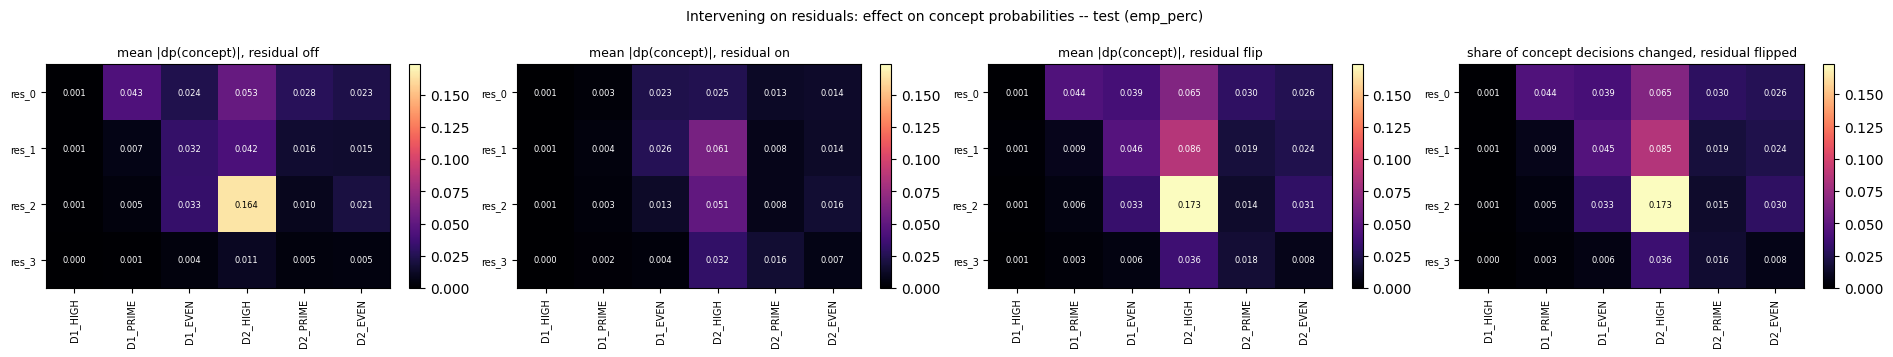

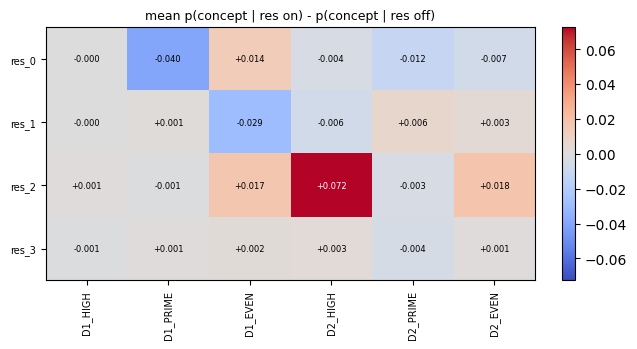

In [17]:
# Residual -> concept interventions with the codebase's own SCBM intervention
# (SCBM_Strategy.compute_intervention in utils/intervention.py, the step
# intervene_scbm_residual_optimized runs), with the mask on one residual instead of on concepts.
# Reuses DATA / SPLIT / NUM_CONCEPTS / NUM_RESIDUALS / CONCEPT_NAMES / RESIDUAL_NAMES / plot_matrix.
from omegaconf import OmegaConf

from utils.intervention import EmpiricalPercentileStrategy, SCBM_Strategy
from utils.utils import numerical_stability_check

RC_SPLIT = SPLIT
RC_STRATEGY = "emp_perc"      # "simple_perc" | "emp_perc" | "conf_interval_optimal"; see the markdown
RC_MC = 100                   # Monte Carlo samples, as num_monte_carlo in training
RC_BATCH = 2000
C, R = NUM_CONCEPTS, NUM_RESIDUALS

# In residual mode SCBM_Strategy pads the mask with zeros for the residuals, so they can never be
# intervened on. Declaring the whole [concepts | residuals] vector as one C+R bottleneck
# (model="scbm") lets the mask select a residual; the conditioning maths is unchanged.
# emp_perc normally needs train_loader and the model in its constructor, so build with simple_perc
# here and swap the empirical strategy in below.
rc_strategy = SCBM_Strategy("simple_perc" if RC_STRATEGY == "emp_perc" else RC_STRATEGY,
                            None, None, torch.device("cpu"), OmegaConf.create({
    # level is only read by conf_interval_optimal: the confidence level of the region whose boundary
    # the intervened logit is moved to. Taken from the run's own config (0.99 by default).
    "model": {"model": "scbm", "num_monte_carlo": RC_MC, "inter_strategy": RC_STRATEGY,
              "level": CONFIG["model"].get("level", 0.99)},
    "data": {"num_concepts": C + R},
}))

if RC_STRATEGY == "emp_perc":
    # EmpiricalPercentileStrategy sets the intervened dimension to the 5th / 95th percentile of its
    # predicted probability over the training set, which it gets by running the model over
    # train_loader. The saved train dump holds exactly those probabilities (MC mean per sample), so the
    # percentiles are taken from it; compute_intervened_logits is the unchanged codebase method.
    train_probs = torch.load(RUN / "train" / "concepts_residuals_pred_probs_mean.pt",
                             map_location="cpu").double()                        # [N_train, C+R]
    emp_perc = EmpiricalPercentileStrategy.__new__(EmpiricalPercentileStrategy)
    emp_perc.concept_pred_percentiles = torch.quantile(
        train_probs, q=torch.tensor([0.05, 0.95], dtype=torch.float64), dim=0)   # [2, C+R]
    rc_strategy.interv_strat = emp_perc
    # torch.logit(eps=1e-6) clamps saturated percentiles to about +-13.8.
    target_logits = torch.logit(emp_perc.concept_pred_percentiles[:, C:], eps=1e-6)
    print("emp_perc residual targets (logit):  " + "  ".join(
        f"{name}: off {lo:+.2f} / on {hi:+.2f}"
        for name, lo, hi in zip(RESIDUAL_NAMES, target_logits[0], target_logits[1])))

d = DATA[RC_SPLIT]
mu_all = torch.as_tensor(d["c_res_mu"], dtype=torch.float64)       # [N, C+R]
# Same preparation as the intervention loop: float64, then symmetrise and add jitter to the diagonal
# where Cholesky fails (samples with a collapsed variance are not numerically positive definite).
cov_all = numerical_stability_check(
    torch.as_tensor(d["Sigma"], dtype=torch.float64), device=torch.device("cpu"))  # [N, C+R, C+R]
N = len(mu_all)


@torch.no_grad()
def intervene(target, mask):
    """Concept probabilities and conditional concept means after intervening, batched.

    target, mask: [N, C+R]. Returns p_c [N, C] (MC mean of sigmoid, as in the intervention loop)
    and mu_c [N, C] (conditional mean logit). Intervened dims are residuals, which the conditional
    mean drops, so the first C entries of interv_mu are still the concepts in order.
    """
    p_c, mu_c = [], []
    for s in range(0, N, RC_BATCH):
        sl = slice(s, s + RC_BATCH)
        interv_mu, _, mcmc_probs, _ = rc_strategy.compute_intervention(
            mu_all[sl], cov_all[sl], target[sl], mask[sl])
        p_c.append(mcmc_probs.mean(-1)[:, :C].float())
        mu_c.append(interv_mu[:, :C].float())
    return torch.cat(p_c).numpy(), torch.cat(mu_c).numpy()


torch.manual_seed(0)
no_mask = torch.zeros(N, C + R, dtype=torch.float64)
p0, _ = intervene(no_mask, no_mask)                  # no intervention, same MC pipeline
p0_again, _ = intervene(no_mask, no_mask)            # second draw: the MC noise floor
noise_floor = np.abs(p0_again - p0).mean(0)
res_on_before = d["c_res_mu"][:, C:] > 0             # residual state before intervening

# Three settings per residual: off (p=0.05), on (p=0.95), flip (to the opposite of its current state).
settings = ("off", "on", "flip")
delta_p = np.zeros((len(settings), R, N, C))         # p_c(after) - p_c(before)
delta_mu = np.zeros((len(settings), R, N, C))        # conditional mean logit shift
for s, setting in enumerate(settings):
    for k in range(R):
        mask = no_mask.clone()
        mask[:, C + k] = 1
        target = no_mask.clone()
        if setting == "on":
            target[:, C + k] = 1
        elif setting == "flip":
            target[:, C + k] = torch.as_tensor(~res_on_before[:, k], dtype=torch.float64)
        p, mu_c = intervene(target, mask)
        delta_p[s, k] = p - p0
        delta_mu[s, k] = mu_c - d["c_res_mu"][:, :C]

abs_dp = np.abs(delta_p).mean(2)                     # [settings, R, C]
signed_dp = delta_p.mean(2)
# Share of samples whose concept decision (p > 0.5) changes under the flip.
bit_flip = ((p0 > 0.5)[None] != ((p0[None] + delta_p[settings.index("flip")]) > 0.5)).mean(1)   # [R, C]

short = [n.split("(")[0] for n in CONCEPT_NAMES]
print(f"{RUN.name}\nsplit = {RC_SPLIT}   strategy = {RC_STRATEGY}   MC = {RC_MC}\n")
print("mean Sigma_cc (concepts with ~0 variance cannot move under any intervention):")
print("  " + "  ".join(f"{n}={v:.3f}" for n, v in zip(short, np.einsum('nii->i', d['Sigma'][:, :C, :C]) / N)))
print("MC noise floor of mean |dp|: " + "  ".join(f"{n}={v:.4f}" for n, v in zip(short, noise_floor)))

for s, setting in enumerate(settings):
    print(f"\n== residual set {setting}: mean |dp(concept)|  (signed mean in brackets) ==")
    print(f"{'':<8}" + "".join(f"{n:>17}" for n in short) + f"{'moves most':>14}")
    for k in range(R):
        cells = "".join(f"{abs_dp[s, k, j]:>8.3f} ({signed_dp[s, k, j]:+.3f})" for j in range(C))
        print(f"{RESIDUAL_NAMES[k]:<8}{cells}{short[abs_dp[s, k].argmax()]:>14}")

print(f"\n== residual flipped: share of samples whose concept decision (p > 0.5) changes ==")
print(f"{'':<8}" + "".join(f"{n:>10}" for n in short))
for k in range(R):
    print(f"{RESIDUAL_NAMES[k]:<8}" + "".join(f"{v:>10.3f}" for v in bit_flip[k]))


def residual_by_concept(matrix, title, ax, cmap="magma", vmin=0, vmax=None, fmt="{:.3f}"):
    """[R, C] heatmap: rows = intervened residual, columns = concept."""
    vmax = vmax if vmax is not None else max(np.nanmax(np.abs(matrix)), 1e-6)
    im = ax.imshow(matrix, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(C), short, rotation=90, fontsize=7)
    ax.set_yticks(range(R), RESIDUAL_NAMES, fontsize=7)
    for i in range(R):
        for j in range(C):
            shade = (matrix[i, j] - vmin) / (vmax - vmin)
            ax.text(j, i, fmt.format(matrix[i, j]), ha="center", va="center", fontsize=6,
                    color="w" if (shade < 0.55 if cmap == "magma" else abs(shade - 0.5) > 0.3) else "k")
    ax.set_title(title, fontsize=9)
    ax.figure.colorbar(im, ax=ax, fraction=0.046)


fig, axes = plt.subplots(1, 4, figsize=(19, 3.6))
vmax = abs_dp.max()
for s, setting in enumerate(settings):
    residual_by_concept(abs_dp[s], f"mean |dp(concept)|, residual {setting}", axes[s], vmax=vmax)
residual_by_concept(bit_flip, "share of concept decisions changed, residual flipped", axes[3])
fig.suptitle(f"Intervening on residuals: effect on concept probabilities -- {RC_SPLIT} "
             f"({RC_STRATEGY})", fontsize=10)
fig.tight_layout()
plt.show()

# Signed: on minus off is the direction each concept is pushed when the residual turns on.
fig, ax = plt.subplots(figsize=(6.5, 3.6))
on_minus_off = signed_dp[settings.index("on")] - signed_dp[settings.index("off")]
lim = max(np.abs(on_minus_off).max(), 1e-6)
residual_by_concept(on_minus_off, "mean p(concept | res on) - p(concept | res off)", ax,
                    cmap="coolwarm", vmin=-lim, vmax=lim, fmt="{:+.3f}")
fig.tight_layout()
plt.show()

### 4d. Residual on → off: concept movement per digit pair

For each residual `k` (all four, one at a time) and each concept, this measures how the concept
probability changes when the residual goes from on to off:

    contrast = p(concept | res_k set to 1) - p(concept | res_k set to 0)

Positive (red) means the concept is more likely when `res_k` is on; negative (blue) means less likely.

**Why on minus off rather than each setting against the baseline.** Comparing one setting with the
unintervened prediction depends on where the residual's logit started. res_2 often sits around +41,
so even "set to 1" (the `emp_perc` target, logit +13.82) drags it down by about 27 logits and moves
the concepts a lot. Subtracting the two settings cancels the starting point: the concept's
conditional mean logit changes by `Sigma_cr / Sigma_rr × 27.6` (the gap between the ±13.82 targets),
which depends only on the predicted coupling. The probability change still depends on how saturated
the concept is.

No new sampling: the cell subtracts the two settings section 4c already computed, then groups by the
oracle digits (about 100 test samples per pair).

- **Figure 1:** pooled over all samples, as reference. Signed mean (direction) and mean `|contrast|`
  (size, so opposite-sign samples don't cancel).
- **Figures 2–5: one per residual switched** (res_0 … res_3). Each has 6 panels, one per concept,
  and each panel is a 10×10 map over `(d1, d2)` (rows d1, columns d2) of the mean signed contrast
  over that pair's samples. All four figures share one colour scale, so residuals compare directly.
  Red ticks mark the concept-ambiguous digits `{0,4}`, `{5,7}`, `{6,8}`.
- **The printed list:** the 15 largest per-pair movements. A signed mean much smaller than the
  mean `|.|` means the samples in that pair disagree on the direction.

The 4c caveats still apply. The contrast is a conditional update, not a causal effect. A concept can
only move if it still has variance (D1_HIGH can't). The targets are the `emp_perc` values from 4c
(logit ±13.82 on this run).

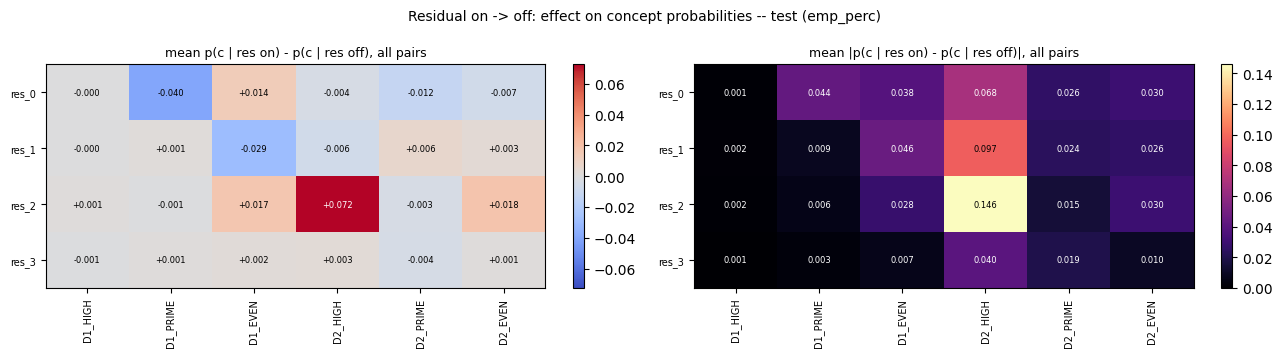

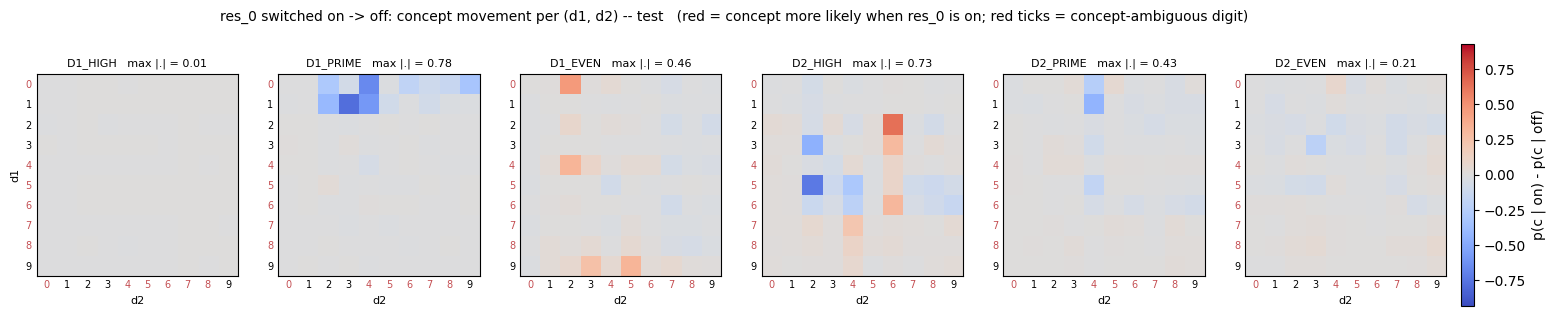

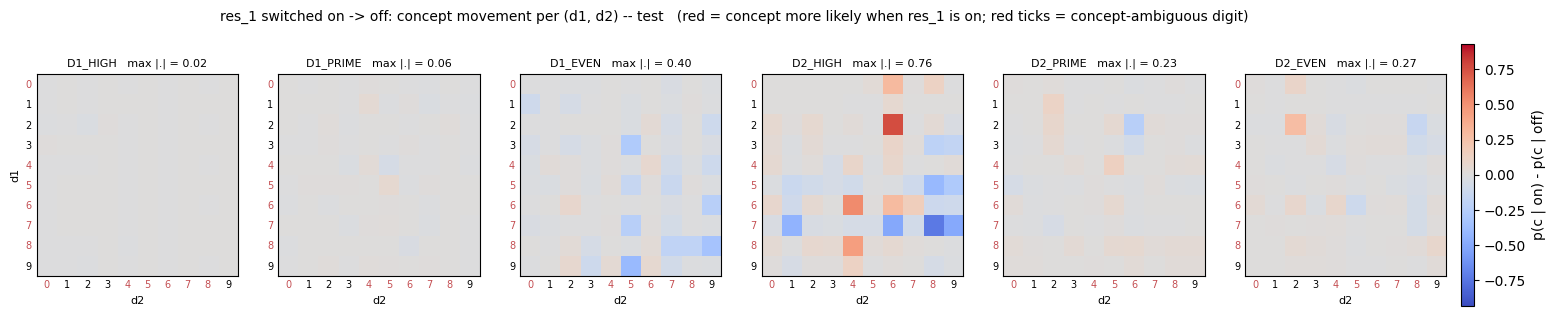

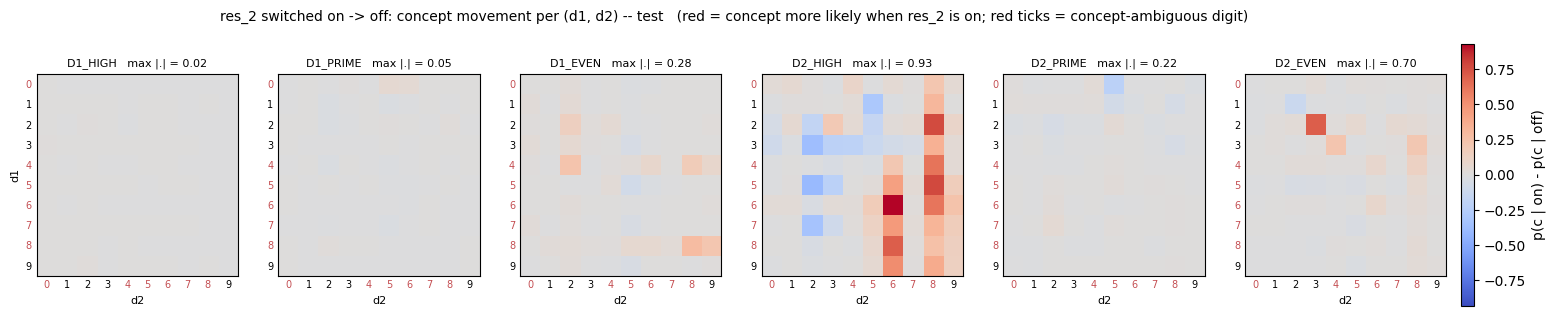

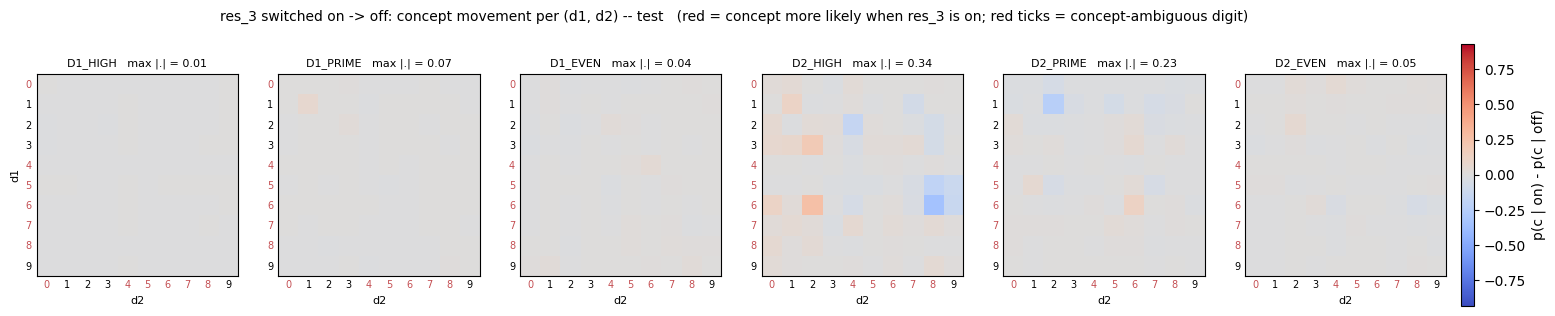

top 15 on -> off movements  (exact_digit_sum_exact_digit_R4_gauss05_prec_00_mlp_head_2026-09-14_20-30-47_seed_0_fb678, test)

 mean |.|     mean  residual  (d1, d2)  concept   
    0.930   +0.930  res_2     (6, 6)    D2_HIGH   
    0.808   +0.768  res_2     (2, 8)    D2_HIGH   
    0.782   -0.782  res_0     (1, 3)    D1_PRIME  
    0.775   +0.775  res_2     (5, 8)    D2_HIGH   
    0.761   +0.761  res_1     (2, 6)    D2_HIGH   
    0.732   -0.732  res_0     (5, 2)    D2_HIGH   
    0.732   -0.732  res_1     (7, 8)    D2_HIGH   
    0.699   +0.699  res_2     (2, 3)    D2_EVEN   
    0.698   +0.698  res_2     (8, 6)    D2_HIGH   
    0.657   -0.657  res_0     (0, 4)    D1_PRIME  
    0.635   +0.635  res_0     (2, 6)    D2_HIGH   
    0.621   +0.620  res_2     (4, 8)    D2_HIGH   
    0.614   +0.614  res_2     (6, 8)    D2_HIGH   
    0.584   -0.584  res_0     (1, 4)    D1_PRIME  
    0.579   +0.524  res_1     (6, 4)    D2_HIGH   


In [18]:
# Concept movement when a residual goes from on to off, per digit pair (d1, d2).
#
#     contrast = p(concept | res_k set to 1) - p(concept | res_k set to 0)
#
# Reuses the section 4c interventions -- no new sampling. delta_p[setting, residual, sample, concept]
# is p(concept | residual set) - p(concept), so on minus off cancels the unintervened baseline and,
# with it, where the residual's logit started. Positive = the concept is more likely when res_k is on.
# Reuses delta_p / settings / short / RC_SPLIT / residual_by_concept (4c), AMBIGUOUS (section 1) and
# mark_ambiguous (the per-pair residual probability cell in section 3).
digits_rc = DATA[RC_SPLIT]["digits"]
assert len(digits_rc) == delta_p.shape[2], "digits and intervention results are misaligned"

contrast = delta_p[settings.index("on")] - delta_p[settings.index("off")]    # [R, N, C]

# Per (d1, d2): mean signed contrast (direction) and mean |contrast| (size, no cancellation).
pair_signed = np.full((10, 10, R, C), np.nan)
pair_abs = np.full((10, 10, R, C), np.nan)
for a in range(10):
    for b in range(10):
        cell = (digits_rc[:, 0] == a) & (digits_rc[:, 1] == b)
        if cell.any():
            pair_signed[a, b] = contrast[:, cell].mean(1)
            pair_abs[a, b] = np.abs(contrast[:, cell]).mean(1)

# Pooled over all samples first, as the reference for the per-pair grid.
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
lim = max(np.abs(contrast.mean(1)).max(), 1e-6)
residual_by_concept(contrast.mean(1), "mean p(c | res on) - p(c | res off), all pairs", axes[0],
                    cmap="coolwarm", vmin=-lim, vmax=lim, fmt="{:+.3f}")
residual_by_concept(np.abs(contrast).mean(1), "mean |p(c | res on) - p(c | res off)|, all pairs",
                    axes[1])
fig.suptitle(f"Residual on -> off: effect on concept probabilities -- {RC_SPLIT} ({RC_STRATEGY})",
             fontsize=10)
fig.tight_layout()
plt.show()

# One figure per residual switched. Each panel is one concept: a 10x10 map over (d1, d2) of the mean
# signed contrast in that pair. One colour scale across all figures, so residuals compare directly.
lim = max(np.nanmax(np.abs(pair_signed)), 1e-6)
for k in range(R):
    fig, axes = plt.subplots(1, C, figsize=(3.1 * C, 3.4), squeeze=False)
    for j, ax in enumerate(axes[0]):
        im = ax.imshow(pair_signed[:, :, k, j], cmap="coolwarm", vmin=-lim, vmax=lim)
        ax.set_xticks(range(10)); ax.set_yticks(range(10))
        ax.tick_params(labelsize=7, length=0)
        mark_ambiguous(ax)
        ax.set_xlabel("d2", fontsize=8)
        if j == 0:
            ax.set_ylabel("d1", fontsize=8)
        ax.set_title(f"{short[j]}   max |.| = {np.nanmax(np.abs(pair_signed[:, :, k, j])):.2f}",
                     fontsize=8)
    fig.colorbar(im, ax=axes, fraction=0.012, pad=0.01, label="p(c | on) - p(c | off)")
    fig.suptitle(f"{RESIDUAL_NAMES[k]} switched on -> off: concept movement per (d1, d2) -- {RC_SPLIT}"
                 f"   (red = concept more likely when {RESIDUAL_NAMES[k]} is on; "
                 f"red ticks = concept-ambiguous digit)", fontsize=10)
    plt.show()

# The largest per-pair movements. |mean| well below mean|.| means the samples in that pair disagree
# on the direction.
flat = [(pair_abs[a, b, k, j], pair_signed[a, b, k, j], k, a, b, j)
        for k in range(R) for a in range(10) for b in range(10) for j in range(C)]
flat.sort(key=lambda t: -np.nan_to_num(t[0]))
print(f"top 15 on -> off movements  ({RUN.name}, {RC_SPLIT})\n")
print(f"{'mean |.|':>9}{'mean':>9}  {'residual':<10}{'(d1, d2)':<10}{'concept':<10}")
for size, signed, k, a, b, j in flat[:15]:
    print(f"{size:>9.3f}{signed:>+9.3f}  {RESIDUAL_NAMES[k]:<10}{f'({a}, {b})':<10}{short[j]:<10}")

### 4e. Coupling vs saturation: concept shift in its own SDs

The 4d readout is a change in probability, which mixes two things: **how strongly a concept is
coupled to the residual**, and **how close that concept already is to 0 or 1**. A concept at logit
+34 won't visibly change in probability even if it is strongly coupled. This section separates them
by reporting two numbers for each residual on → off:

    z  = (mu_c | res_k on  -  mu_c | res_k off) / sd_c     how many of its own SDs the concept moves
    dp = p(c | res_k on)   -  p(c | res_k off)              the practical effect (4d)

`mu_c | ...` is the conditional mean logit 4c already computes (`delta_mu`), and `sd_c` is the
concept's predicted SD before intervening. In the Gaussian `z = rho(c, r_k) × 27.6 / sd_r_k`, where
27.6 is the gap between the ±13.82 `emp_perc` targets. It depends only on the coupling, not on where
the concept's logit sits, so it is comparable across concepts and pairs.

**Reading the two together:**

- **Large `z`, small `dp`:** a real coupling hidden by saturation.
- **Small `z`, large `dp`:** a weak coupling that only matters because the concept sits near 0.5.
- **D1_HIGH:** where its variance has collapsed (`Sigma_cc <= VAR_EPS`, the section 4 cutoff), `z` is
  a ratio of rounding errors and is set to NaN. The printed "usable variance" line gives the share
  kept per concept.

**Outputs:** pooled heatmaps (median `|z|`, mean `|dp|`), a scatter with one point per
`(d1, d2)` × concept per residual, split by `Z_LARGE` / `DP_LARGE` into the four cases above (with
counts and the top cases of each surprising kind), and per-residual `(d1, d2)` maps of median signed
`z`, the counterpart of the 4d maps. Medians are used because `z` has heavy tails where `sd_r` is small.

**Caveat on the threshold.** The `emp_perc` push is large (27.6 logits), so concepts typically move
10–40 of their own SDs, and a fixed `Z_LARGE = 1` puts almost every case in "hidden by saturation".
Whether a shift is large enough to matter depends on how far the concept is from 0.5 in its own SDs,
`|mu_c| / sd_c`, which on this run is often tens of SDs. Read `z` against that distance rather than
against a fixed cutoff.

The 4c caveats still apply: `z` measures coupling in the model's predicted Gaussian (conditioning,
not causation).

exact_digit_sum_exact_digit_R4_gauss05_prec_00_mlp_head_2026-09-14_20-30-47_seed_0_fb678
split = test   strategy = emp_perc

samples with usable concept variance (Sigma_cc > VAR_EPS): D1_HIGH=0.115  D1_PRIME=0.943  D1_EVEN=0.999  D2_HIGH=1.000  D2_PRIME=1.000  D2_EVEN=1.000

== pooled: median |z| (concept SDs)  /  mean |dp| ==
                  D1_HIGH         D1_PRIME          D1_EVEN          D2_HIGH         D2_PRIME          D2_EVEN
res_0       25.31 / 0.001    16.81 / 0.044    16.25 / 0.038    17.29 / 0.068    17.24 / 0.026    13.77 / 0.030
res_1       38.52 / 0.002    21.39 / 0.009    20.74 / 0.046    19.84 / 0.097    23.72 / 0.024    14.15 / 0.026
res_2       27.01 / 0.002    11.02 / 0.006    10.10 / 0.028    15.84 / 0.146    11.63 / 0.015    13.99 / 0.030
res_3        9.66 / 0.001     4.37 / 0.003     5.99 / 0.007     9.99 / 0.040    11.75 / 0.019     8.76 / 0.010


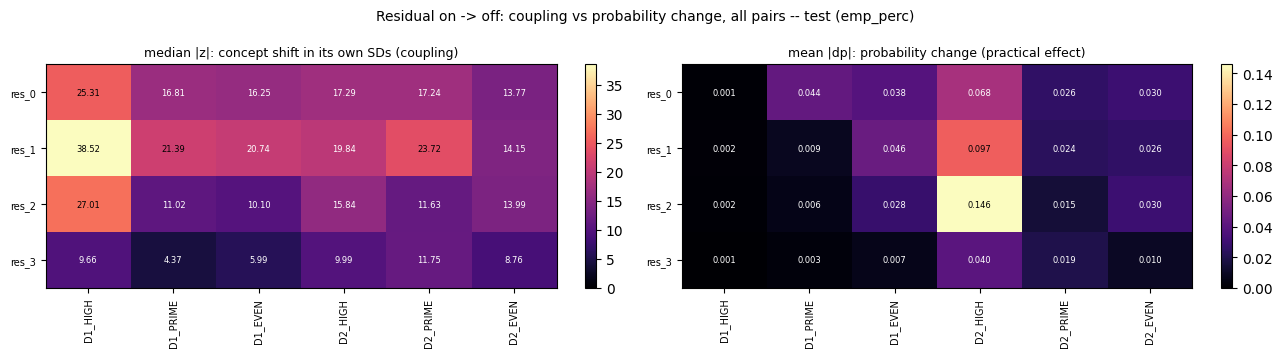

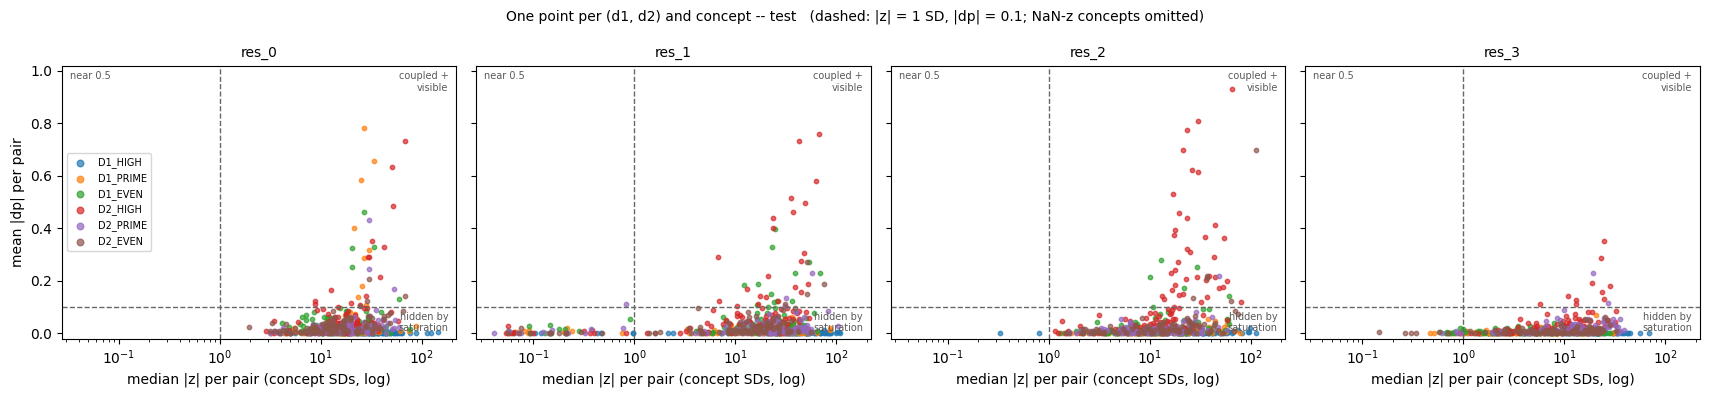


== per (d1, d2): how the 100 pairs x 6 concepts fall, per residual (|z| >= 1, |dp| >= 0.1) ==
           coupled, hidden by saturation             coupled and visible      weak, but concept near 0.5                       no effect   NaN z
res_0                                548                              35                               0                               0      17
res_1                                474                              42                               1                              66      17
res_2                                533                              48                               0                               2      17
res_3                                540                              12                               0                              31      17

largest coupling hidden by saturation (|dp| < DP_LARGE)
     |z|        z    |dp|  residual  (d1, d2)  concept   
  146.53  +146.53   0.007  res_0     (5, 2)    D1_HIGH   
  124.3

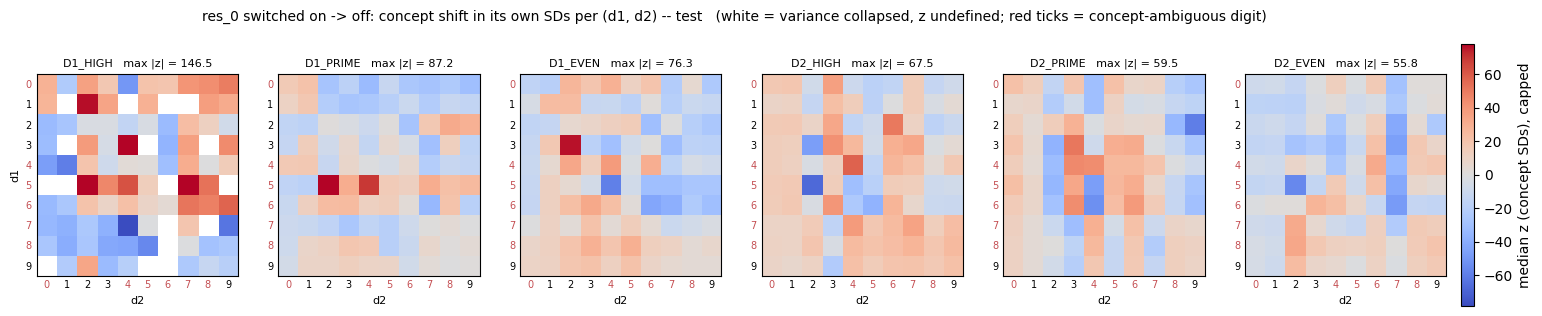

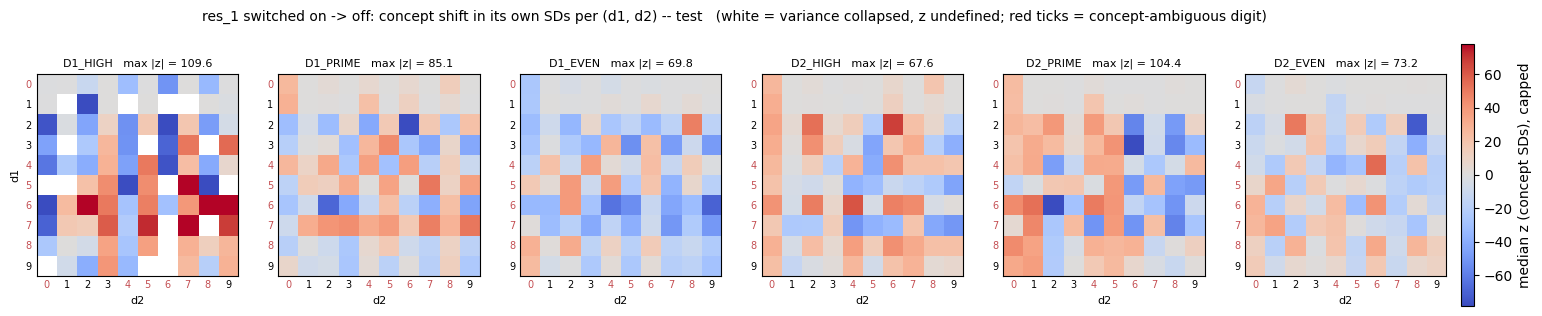

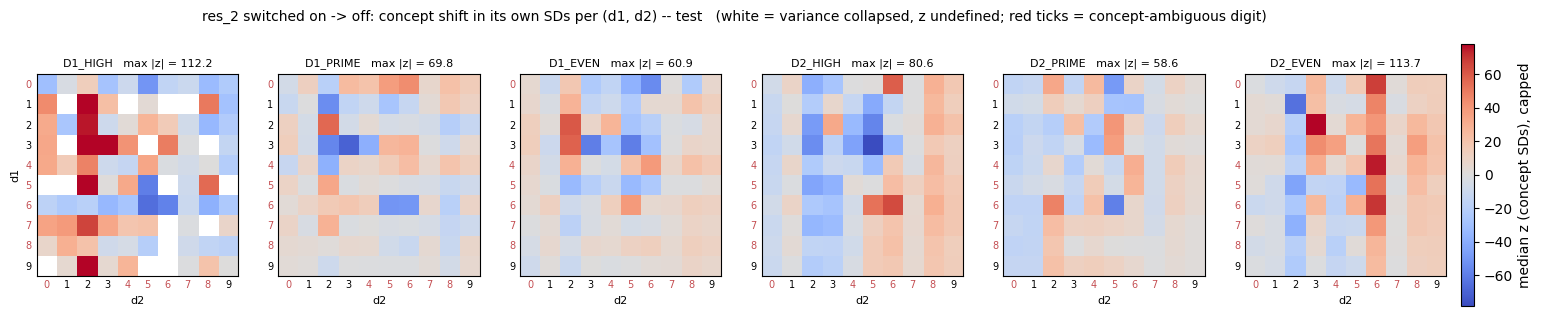

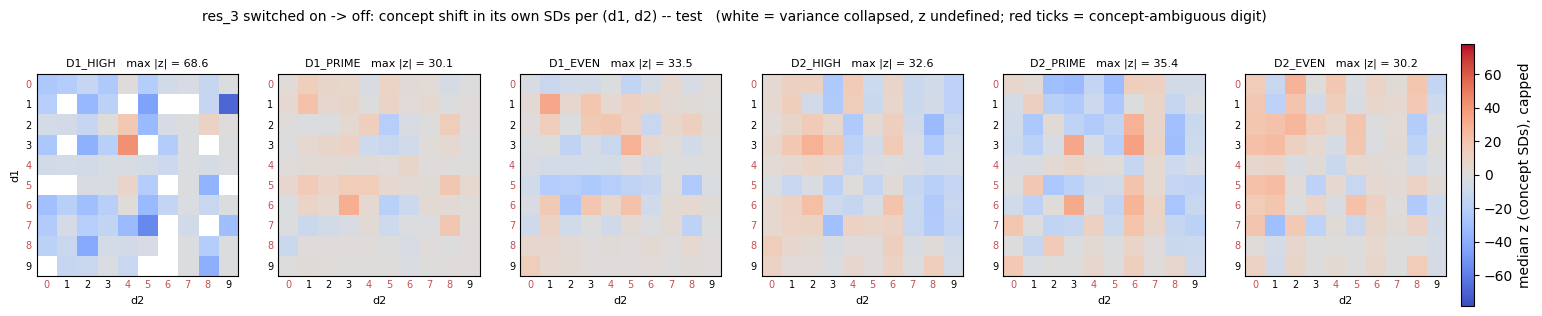

In [19]:
# Coupling vs saturation: the standardised concept logit shift next to the probability change, when a
# residual goes from on to off.
#
#   z  = (mu_c | res_k on  -  mu_c | res_k off) / sd_c     how many of its own SDs the concept moves
#   dp = p(c | res_k on)   -  p(c | res_k off)              the practical effect (`contrast`, 4d)
#
# In the Gaussian, z = rho(c, r_k) * (eta*_on - eta*_off) / sd_r_k: it depends only on the predicted
# coupling and the target gap, not on where the concept's logit sits, so it is comparable across
# concepts and pairs. sd_c is the concept's predicted SD before intervening. Where Sigma_cc <= VAR_EPS
# (a collapsed variance, e.g. D1_HIGH) z is a ratio of rounding errors and is set to NaN.
# Reuses delta_mu / settings / d / short / residual_by_concept (4c), contrast / pair_abs / digits_rc
# (4d), VAR_EPS (section 4), mark_ambiguous and AMBIGUOUS.
import warnings

Z_LARGE = 1.0     # |z| >= this: the concept moves by at least one of its own SDs
DP_LARGE = 0.1    # |dp| >= this: a visible change in probability

dmu = delta_mu[settings.index("on")] - delta_mu[settings.index("off")]          # [R, N, C]
var_c = np.einsum("nii->ni", d["Sigma"][:, :C, :C]).astype(np.float64)          # [N, C]
valid_c = var_c > VAR_EPS
z = np.where(valid_c[None], dmu / np.sqrt(np.clip(var_c, VAR_EPS, None))[None], np.nan)   # [R, N, C]


def nan_median(x, axis):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)   # all-NaN slices -> NaN
        return np.nanmedian(x, axis=axis)


# Pooled over all samples. The median, because z has heavy tails where sd_r is small.
pooled_z = nan_median(np.abs(z), axis=1)          # [R, C]
pooled_dp = np.abs(contrast).mean(1)              # [R, C]

print(f"{RUN.name}\nsplit = {RC_SPLIT}   strategy = {RC_STRATEGY}\n")
print("samples with usable concept variance (Sigma_cc > VAR_EPS): " + "  ".join(
    f"{n}={v:.3f}" for n, v in zip(short, valid_c.mean(0))))
print(f"\n== pooled: median |z| (concept SDs)  /  mean |dp| ==")
print(f"{'':<8}" + "".join(f"{n:>17}" for n in short))
for k in range(R):
    print(f"{RESIDUAL_NAMES[k]:<8}" + "".join(
        f"{pooled_z[k, j]:>9.2f} / {pooled_dp[k, j]:.3f}" for j in range(C)))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
residual_by_concept(np.nan_to_num(pooled_z), "median |z|: concept shift in its own SDs (coupling)",
                    axes[0], fmt="{:.2f}")
residual_by_concept(pooled_dp, "mean |dp|: probability change (practical effect)", axes[1])
fig.suptitle(f"Residual on -> off: coupling vs probability change, all pairs -- {RC_SPLIT} "
             f"({RC_STRATEGY})", fontsize=10)
fig.tight_layout()
plt.show()

# Per (d1, d2): median signed / absolute z. The |dp| partner is pair_abs from 4d.
pair_z_signed = np.full((10, 10, R, C), np.nan)
pair_z_abs = np.full((10, 10, R, C), np.nan)
for a in range(10):
    for b in range(10):
        cell = (digits_rc[:, 0] == a) & (digits_rc[:, 1] == b)
        if cell.any():
            pair_z_signed[a, b] = nan_median(z[:, cell], axis=1)
            pair_z_abs[a, b] = nan_median(np.abs(z[:, cell]), axis=1)

# One point per (residual, concept, pair): x = coupling, y = practical effect.
groups = {
    "coupled, hidden by saturation": lambda zz, pp: (zz >= Z_LARGE) & (pp < DP_LARGE),
    "coupled and visible": lambda zz, pp: (zz >= Z_LARGE) & (pp >= DP_LARGE),
    "weak, but concept near 0.5": lambda zz, pp: (zz < Z_LARGE) & (pp >= DP_LARGE),
    "no effect": lambda zz, pp: (zz < Z_LARGE) & (pp < DP_LARGE),
}
fig, axes = plt.subplots(1, R, figsize=(4.3 * R, 4.0), sharex=True, sharey=True, squeeze=False)
x_floor = 1e-3
for k, ax in enumerate(axes[0]):
    for j in range(C):
        zz, pp = pair_z_abs[:, :, k, j].ravel(), pair_abs[:, :, k, j].ravel()
        keep = ~np.isnan(zz)
        ax.scatter(np.clip(zz[keep], x_floor, None), pp[keep], s=10, alpha=0.7, color=f"C{j}",
                   label=short[j] if k == 0 else None)
    ax.axvline(Z_LARGE, color="0.4", ls="--", lw=1)
    ax.axhline(DP_LARGE, color="0.4", ls="--", lw=1)
    ax.set_xscale("log")
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel("median |z| per pair (concept SDs, log)")
    ax.set_title(RESIDUAL_NAMES[k], fontsize=10)
    for text, (x, y, ha, va) in {
        "hidden by\nsaturation": (0.98, 0.02, "right", "bottom"),
        "coupled +\nvisible": (0.98, 0.98, "right", "top"),
        "near 0.5": (0.02, 0.98, "left", "top"),
    }.items():
        ax.text(x, y, text, transform=ax.transAxes, ha=ha, va=va, fontsize=7, color="0.35")
axes[0, 0].set_ylabel("mean |dp| per pair")
axes[0, 0].legend(fontsize=7, loc="center left", markerscale=1.5)
fig.suptitle(f"One point per (d1, d2) and concept -- {RC_SPLIT}   "
             f"(dashed: |z| = {Z_LARGE:g} SD, |dp| = {DP_LARGE:g}; NaN-z concepts omitted)",
             fontsize=10)
fig.tight_layout()
plt.show()

print(f"\n== per (d1, d2): how the {100} pairs x {C} concepts fall, per residual "
      f"(|z| >= {Z_LARGE:g}, |dp| >= {DP_LARGE:g}) ==")
print(f"{'':<8}" + "".join(f"{g:>32}" for g in groups) + f"{'NaN z':>8}")
for k in range(R):
    zz, pp = pair_z_abs[:, :, k].ravel(), pair_abs[:, :, k].ravel()
    keep = ~np.isnan(zz)
    print(f"{RESIDUAL_NAMES[k]:<8}" + "".join(
        f"{int(rule(zz[keep], pp[keep]).sum()):>32}" for rule in groups.values())
        + f"{int((~keep).sum()):>8}")

flat = [(pair_z_abs[a, b, k, j], pair_abs[a, b, k, j], pair_z_signed[a, b, k, j], k, a, b, j)
        for k in range(R) for a in range(10) for b in range(10) for j in range(C)
        if not np.isnan(pair_z_abs[a, b, k, j])]
for title, rows in (
    ("largest coupling hidden by saturation (|dp| < DP_LARGE)",
     sorted([r for r in flat if r[1] < DP_LARGE], key=lambda r: -r[0])),
    ("largest probability change with weak coupling (|z| < Z_LARGE)",
     sorted([r for r in flat if r[0] < Z_LARGE], key=lambda r: -r[1])),
):
    print(f"\n{title}")
    print(f"{'|z|':>8}{'z':>9}{'|dp|':>8}  {'residual':<10}{'(d1, d2)':<10}{'concept':<10}")
    for zabs, dpabs, zsig, k, a, b, j in rows[:10]:
        print(f"{zabs:>8.2f}{zsig:>+9.2f}{dpabs:>8.3f}  {RESIDUAL_NAMES[k]:<10}"
              f"{f'({a}, {b})':<10}{short[j]:<10}")

# Per residual: signed median z per (d1, d2), the coupling counterpart of the 4d maps. The colour
# scale is capped at the 99th percentile of |z| so a few extreme pairs don't wash the maps out.
lim = max(np.nanpercentile(np.abs(pair_z_signed), 99), 1e-6)
for k in range(R):
    fig, axes = plt.subplots(1, C, figsize=(3.1 * C, 3.4), squeeze=False)
    for j, ax in enumerate(axes[0]):
        im = ax.imshow(pair_z_signed[:, :, k, j], cmap="coolwarm", vmin=-lim, vmax=lim)
        ax.set_xticks(range(10)); ax.set_yticks(range(10))
        ax.tick_params(labelsize=7, length=0)
        mark_ambiguous(ax)
        ax.set_xlabel("d2", fontsize=8)
        if j == 0:
            ax.set_ylabel("d1", fontsize=8)
        ax.set_title(f"{short[j]}   max |z| = {np.nanmax(np.abs(pair_z_signed[:, :, k, j])):.1f}"
                     if not np.isnan(pair_z_signed[:, :, k, j]).all() else f"{short[j]}   (all NaN)",
                     fontsize=8)
    fig.colorbar(im, ax=axes, fraction=0.012, pad=0.01, label="median z (concept SDs), capped")
    fig.suptitle(f"{RESIDUAL_NAMES[k]} switched on -> off: concept shift in its own SDs per (d1, d2) "
                 f"-- {RC_SPLIT}   (white = variance collapsed, z undefined; red ticks = concept-ambiguous digit)",
                 fontsize=10)
    plt.show()

## 4f. The residual code book, and which bit the head reads

The residuals are nearly binary (section 3), so thresholding the R residual probabilities at 0.5
gives an R-bit **code** per sample. This section reads that code directly, then swaps it one bit at
a time. It is self-contained: it loads the head from `model.pth`, thresholds the saved channel, and
takes the *typical* code of each `(d1, d2)` pair as the most frequent code on `CODE_SPLIT = train`.

**1a. Code per digit and position.** For each digit 0–9 at each position, the distribution of codes
with the other digit marginalised. If the code for "d1 = 4" is the same whatever d2 is, the channel
encodes **digit identity per position**; if the modal code's share is well below the purity of the
individual pairs, the code only makes sense for the **pair** (sum-level, or entangled). The per-bit
table asks the same per residual: how much of a bit's digit information is about d1, about d2, or
only about the pair (`I(bit; d1, d2)` much larger than either marginal).

**1b. Bits beyond the concepts.** `H(y | c_true)` is what the six concept bits leave unknown about
the sum (the concept-only ceiling of section 1 in bits), `H(d1, d2 | c)` the same for digit identity.
`I(code; y | c)` and `I(code; d1, d2 | c)` are how much of that the code recovers; `H(code | c)` is
the capacity the code actually uses within a concept cell (at most R bits). `y` is a function of the
digits, so `I(code; y | c) ≤ I(code; d1, d2 | c)`: a gap between them is digit information the sum
does not need. These are plug-in estimates on ~10k samples over up to 49 × 16 cells, so they are
biased upward; the `shuffled` columns (code permuted within each concept cell) give the bias floor.

**1c. Code consistency vs errors.** Per pair, the share of samples carrying the pair's modal code
(purity), against the pair's accuracy; and accuracy split by whether a sample carries its modal
code. If errors concentrate on non-modal codes, the limit is the encoder writing the code, not the
head reading it.

**2. Single-bit swaps.** The whole-code swap (previously 4b: set the residual code to the other
member's typical code and check that the prediction moves by the digit difference) done one bit at
a time, for every ambiguous pair, both directions, both positions:

- **sufficiency:** only bit `k` is set to the target's typical bit. High = that bit alone resolves
  the pair.
- **necessity:** the whole code is swapped *except* bit `k`. A large drop from `full` = the head
  cannot resolve the pair without that bit.
- `bit differs` is the share of samples whose bit `k` actually changes under the swap; where it does
  not, the single-bit swap is a no-op by construction.

**Guardrails.** Thresholding at 0.5 discards the residual's uncertainty; the head normally sees
Bernoulli samples (the old 4b fidelity check put the two at 98.6% agreement on this run). The MI
numbers say what is *recoverable* from the code, and the swaps what the head *uses*; neither says
that a bit *is* a digit. Sufficiency and necessity can both be low for every bit while the full swap
works: that is the signature of a distributed code that the head reads as combinations.

exact_digit_sum_exact_digit_R4_gauss05_prec_00_mlp_head_2026-09-14_20-30-47_seed_0_fb678
R = 4 residual bits -> 16 possible codes

== 1a. code distribution per digit and position (test) ==
modal code given one digit (other digit marginalised) vs mean purity given the full pair.
Equal numbers = the code is fixed by that digit alone; a marginal share well below the pair
purity = the code depends on the other digit too.

        d1: modal  share  pair purity      d2: modal  share  pair purity
0            1100   0.62         0.75           1100   0.62         0.82    
1            1100   0.59         0.75           1100   0.58         0.82    
2            1100   0.29         0.73           1110   0.30         0.78    
3            1100   0.19         0.77           1110   0.20         0.74    
4            1111   0.29         0.78           1011   0.30         0.70    
5            1110   0.33         0.82           1110   0.24         0.76    
6            1110   0.35         0.78      

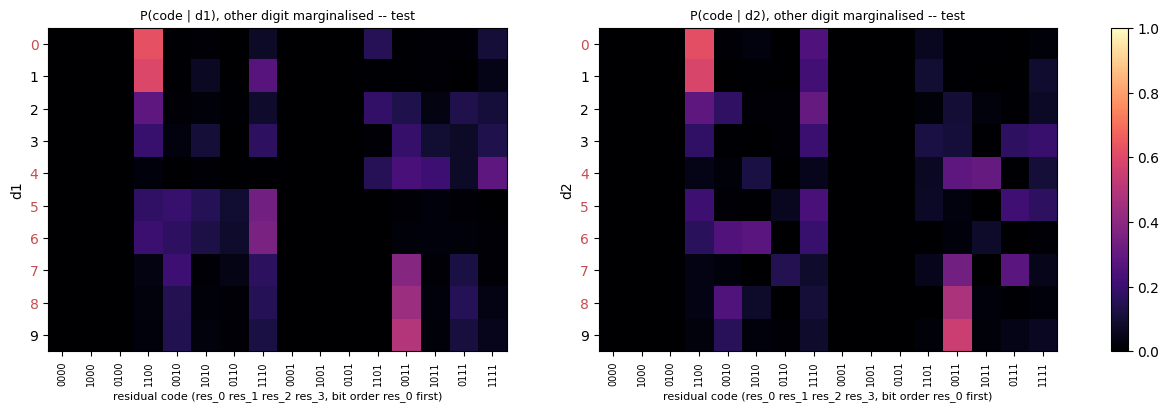


== per bit: information about the digits (test), in bits ==
          H(bit)  I(bit;d1)  I(bit;d2)  I(bit;d1,d2)  position
res_0      0.958      0.251      0.259         0.703 both/pair
res_1      0.960      0.156      0.329         0.645        d2
res_2      0.839      0.230      0.188         0.586 both/pair
res_3      0.990      0.298      0.198         0.676 both/pair

== 1b. what the code carries beyond the concepts, in bits ==
H(.|c) is what the concepts leave unknown; I(code; . | c) is what the code recovers of it.
'shuffled' = the same estimate with the code permuted within each concept cell: the plug-in
bias floor. Bits of the code itself: H(code | c) = capacity actually used.

split   H(code|c)  H(y|c) I(code;y|c)  shuffled  H(d1,d2|c)  I(code;d1,d2|c)  shuffled
train       1.361   1.100       1.061     0.009       1.200            1.075     0.010
val         1.709   1.100       0.790     0.074       1.200            0.809     0.078
test        1.792   1.100       0.757     

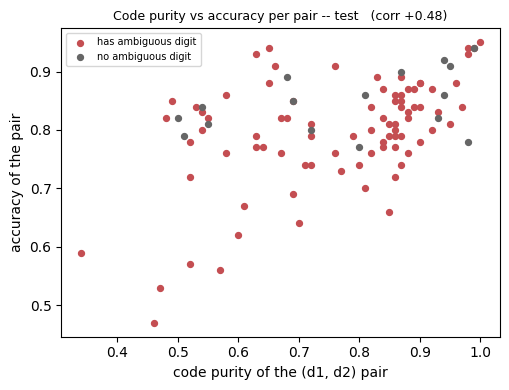


== 2. single-bit swaps: which residual moves the prediction? (intervened on test, typical codes from train) ==
sufficiency: only bit k is set to the target pair's typical bit; the rest stay.
necessity: every bit except k is set to the typical code. Each entry is the share of samples
whose prediction moves by the digit difference; 'full' is the 4b whole-code swap.

swap                full |    res_0   res_1   res_2   res_3  |    res_0   res_1   res_2   res_3
                         |     sufficiency (only bit k)     |      necessity (all but k)      
d1: 0->4 (+4)       0.79 |     0.16    0.01    0.31    0.31  |     0.67    0.70    0.56    0.52
d2: 0->4 (+4)       0.84 |     0.23    0.01    0.18    0.13  |     0.64    0.67    0.44    0.65
d1: 4->0 (-4)       0.84 |     0.09    0.01    0.19    0.24  |     0.59    0.76    0.43    0.54
d2: 4->0 (-4)       0.81 |     0.09    0.02    0.22    0.10  |     0.57    0.58    0.47    0.58
d1: 5->7 (+2)       0.86 |     0.45    0.19    0.17    0.

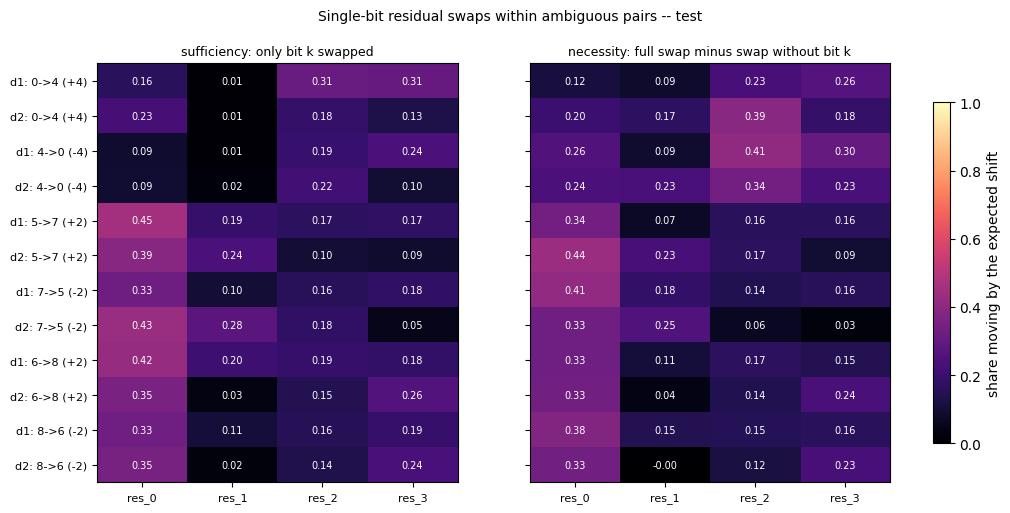

In [20]:
# 4f. The residual code book, and which single bit the head reads.
#
# The residuals are nearly binary, so the R residual probabilities thresholded at 0.5 form an R-bit
# code per sample. Part 1 reads that code against the oracle digits and the sum, in bits. Part 2
# repeats the 4b swap one bit at a time.
# Reuses collisions / AMBIGUOUS (section 1), mark_ambiguous (section 3), DATA / CONFIG / SPLITS /
# RESIDUAL_NAMES.
import torch.nn as nn

CB_SPLIT = SPLIT          # split the code book is read on
INT_SPLIT = SPLIT         # split the single-bit swaps are applied to
CODE_SPLIT = "train"      # split the typical code per (d1, d2) is read from
C, R = NUM_CONCEPTS, NUM_RESIDUALS
K = 2 ** R
BIT_WEIGHTS = 2 ** np.arange(R)                       # code id = sum_k bit_k * 2^k
PERMUTATIONS = 20                                     # shuffle baseline for the plug-in MI estimates
rng_cb = np.random.default_rng(0)

if CONFIG["model"]["concept_learning"] != "hard":
    raise ValueError("the head consumes logits, not bits, so a bit code is not what it reads")


def load_head(run):
    """The task head with the checkpoint's weights, in eval mode (linear or non_linear)."""
    state = torch.load(run / "model.pth", map_location="cpu")
    head_state = {k[len("head."):]: v for k, v in state.items() if k.startswith("head.")}
    hidden, n_in = head_state["0.weight"].shape
    if "2.weight" in head_state:
        head = nn.Sequential(nn.Linear(n_in, hidden), nn.ReLU(),
                             nn.Linear(hidden, head_state["2.weight"].shape[0]))
    else:
        head = nn.Sequential(nn.Linear(n_in, hidden))
    head.load_state_dict(head_state)
    return head.eval()


def binary_channel(split, run=RUN):
    """[N, C+R] concepts and residuals thresholded at p = 0.5: the head's deterministic input."""
    probs = torch.load(run / split / "concepts_residuals_pred_probs_mean.pt", map_location="cpu")
    return (probs.numpy() > 0.5).astype(np.float32)


head = load_head(RUN)


@torch.no_grad()
def predict(x):
    return head(torch.as_tensor(x)).argmax(1).numpy()


# Typical residual code per (d1, d2) on CODE_SPLIT: the most frequent one.
_code_bits = binary_channel(CODE_SPLIT)[:, C:]
_code_digits = DATA[CODE_SPLIT]["digits"]
typical = {}
for a in range(10):
    for b in range(10):
        cell = (_code_digits[:, 0] == a) & (_code_digits[:, 1] == b)
        codes, counts = np.unique(_code_bits[cell], axis=0, return_counts=True)
        typical[a, b] = codes[counts.argmax()]


def code_str(code_id):
    return "".join(str((int(code_id) >> k) & 1) for k in range(R))


def key(*columns):
    """One integer label per distinct combination of the columns."""
    return np.unique(np.stack([np.asarray(c).ravel() for c in columns], 1), axis=0,
                     return_inverse=True)[1].ravel()


def H(*columns):
    """Plug-in joint entropy of the combination, in bits. No columns = nothing to condition on."""
    if not columns:
        return 0.0
    _, counts = np.unique(key(*columns), return_counts=True)
    p = counts / counts.sum()
    return float(-(p * np.log2(p)).sum())


def cond_H(x, *given):
    return H(x, *given) - H(*given)


def cond_MI(x, y, *given):
    """I(x; y | given) = H(x | given) - H(x | y, given)."""
    return cond_H(x, *given) - cond_H(x, y, *given)


def split_codes(split):
    dd = DATA[split]
    bits = binary_channel(split)[:, C:].astype(int)                  # [N, R]
    return {
        "bits": bits,
        "code": bits @ BIT_WEIGHTS,                                  # [N] in 0..K-1
        "d1": dd["digits"][:, 0], "d2": dd["digits"][:, 1],
        "pair": dd["digits"][:, 0] * 10 + dd["digits"][:, 1],
        "y": dd["y_true"], "y_hat": dd["y_hat"],
        "c": key(*dd["c_true"].T),                                   # concept cell id
    }


CB = {split: split_codes(split) for split in SPLITS}
print(f"{RUN.name}\nR = {R} residual bits -> {K} possible codes\n")

# ---------------------------------------------------------------- 1a. code per digit and position
cb = CB[CB_SPLIT]
print(f"== 1a. code distribution per digit and position ({CB_SPLIT}) ==")
print("modal code given one digit (other digit marginalised) vs mean purity given the full pair.")
print("Equal numbers = the code is fixed by that digit alone; a marginal share well below the pair")
print("purity = the code depends on the other digit too.\n")
print(f"{'':<6}{'d1: modal':>11}{'share':>7}{'pair purity':>13}    {'d2: modal':>11}{'share':>7}{'pair purity':>13}")
pair_purity = {}
for a in range(10):
    for b in range(10):
        cell = cb["pair"] == a * 10 + b
        if cell.any():
            pair_purity[a, b] = np.bincount(cb["code"][cell], minlength=K).max() / cell.sum()
code_by_digit = np.zeros((2, 10, K))                                 # P(code | digit at position)
for digit in range(10):
    row = f"{digit:<6}"
    for pos, dcol in enumerate(("d1", "d2")):
        sel = cb[dcol] == digit
        dist = np.bincount(cb["code"][sel], minlength=K) / sel.sum()
        code_by_digit[pos, digit] = dist
        purity_here = np.mean([pair_purity[(digit, o) if pos == 0 else (o, digit)]
                               for o in range(10)])
        row += f"{code_str(dist.argmax()):>11}{dist.max():>7.2f}{purity_here:>13.2f}    "
    print(row)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
for pos, ax in enumerate(axes):
    im = ax.imshow(code_by_digit[pos], cmap="magma", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(K), [code_str(i) for i in range(K)], rotation=90, fontsize=7)
    ax.set_yticks(range(10))
    ax.set_xlabel(f"residual code ({' '.join(RESIDUAL_NAMES)}, bit order res_0 first)", fontsize=8)
    ax.set_ylabel(f"d{pos + 1}")
    for tick in ax.get_yticklabels():           # digit axis only: the x axis holds codes
        if int(tick.get_text()) in AMBIGUOUS:
            tick.set_color("#C44E52")
    ax.set_title(f"P(code | d{pos + 1}), other digit marginalised -- {CB_SPLIT}", fontsize=9)
fig.colorbar(im, ax=axes, fraction=0.02)
plt.show()

# Per bit: how much of its digit information is d1, d2, or only the pair.
print(f"\n== per bit: information about the digits ({CB_SPLIT}), in bits ==")
print(f"{'':<8}{'H(bit)':>8}{'I(bit;d1)':>11}{'I(bit;d2)':>11}{'I(bit;d1,d2)':>14}{'position':>10}")
for k in range(R):
    bit = cb["bits"][:, k]
    i1, i2, i12 = (cond_MI(bit, cb["d1"]), cond_MI(bit, cb["d2"]), cond_MI(bit, cb["pair"]))
    where = "d1" if i1 > 2 * i2 else "d2" if i2 > 2 * i1 else "both/pair"
    print(f"{RESIDUAL_NAMES[k]:<8}{H(bit):>8.3f}{i1:>11.3f}{i2:>11.3f}{i12:>14.3f}{where:>10}")

# ---------------------------------------------------------------- 1b. bits beyond the concepts
print("\n== 1b. what the code carries beyond the concepts, in bits ==")
print("H(.|c) is what the concepts leave unknown; I(code; . | c) is what the code recovers of it.")
print("'shuffled' = the same estimate with the code permuted within each concept cell: the plug-in")
print("bias floor. Bits of the code itself: H(code | c) = capacity actually used.\n")
print(f"{'split':<7}{'H(code|c)':>10}{'H(y|c)':>8}{'I(code;y|c)':>12}{'shuffled':>10}"
      f"{'H(d1,d2|c)':>12}{'I(code;d1,d2|c)':>17}{'shuffled':>10}")
for split, s in CB.items():
    def shuffled(target):
        vals = []
        for _ in range(PERMUTATIONS):
            perm = s["code"].copy()
            for cell_id in np.unique(s["c"]):
                idx = np.flatnonzero(s["c"] == cell_id)
                perm[idx] = perm[rng_cb.permutation(idx)]
            vals.append(cond_MI(perm, target, s["c"]))
        return np.mean(vals)
    print(f"{split:<7}{cond_H(s['code'], s['c']):>10.3f}{cond_H(s['y'], s['c']):>8.3f}"
          f"{cond_MI(s['code'], s['y'], s['c']):>12.3f}{shuffled(s['y']):>10.3f}"
          f"{cond_H(s['pair'], s['c']):>12.3f}{cond_MI(s['code'], s['pair'], s['c']):>17.3f}"
          f"{shuffled(s['pair']):>10.3f}")

# ---------------------------------------------------------------- 1c. code purity vs errors
print(f"\n== 1c. code consistency vs errors ({CB_SPLIT}) ==")
modal_of_pair = {pair: np.bincount(cb["code"][cb["pair"] == pair], minlength=K).argmax()
                 for pair in np.unique(cb["pair"])}
matches_modal = cb["code"] == np.array([modal_of_pair[p] for p in cb["pair"]])
correct = cb["y_hat"] == cb["y"]
print(f"samples carrying their pair's modal code: {matches_modal.mean():.3f}")
print(f"accuracy | modal code: {correct[matches_modal].mean():.3f}    "
      f"accuracy | other code: {correct[~matches_modal].mean():.3f}    "
      f"share of errors with a non-modal code: {(~matches_modal)[~correct].mean():.3f}")

pair_acc_cb = {pair: correct[cb["pair"] == pair].mean() for pair in modal_of_pair}
pairs = sorted(modal_of_pair)
fig, ax = plt.subplots(figsize=(5.2, 4))
xs = [pair_purity[p // 10, p % 10] for p in pairs]
ys = [pair_acc_cb[p] for p in pairs]
amb = [(p // 10 in AMBIGUOUS) or (p % 10 in AMBIGUOUS) for p in pairs]
ax.scatter(np.array(xs)[amb], np.array(ys)[amb], s=18, color="#C44E52", label="has ambiguous digit")
ax.scatter(np.array(xs)[~np.array(amb)], np.array(ys)[~np.array(amb)], s=18, color="0.4",
           label="no ambiguous digit")
ax.set_xlabel("code purity of the (d1, d2) pair")
ax.set_ylabel("accuracy of the pair")
ax.set_title(f"Code purity vs accuracy per pair -- {CB_SPLIT}   "
             f"(corr {np.corrcoef(xs, ys)[0, 1]:+.2f})", fontsize=9)
ax.legend(fontsize=7)
fig.tight_layout()
plt.show()

# ---------------------------------------------------------------- 2. single-bit swaps
print(f"\n== 2. single-bit swaps: which residual moves the prediction? "
      f"(intervened on {INT_SPLIT}, typical codes from {CODE_SPLIT}) ==")
print("sufficiency: only bit k is set to the target pair's typical bit; the rest stay.")
print("necessity: every bit except k is set to the typical code. Each entry is the share of samples")
print("whose prediction moves by the digit difference; 'full' is the 4b whole-code swap.\n")
bits_int = binary_channel(INT_SPLIT)
y0 = predict(bits_int)
swap_labels, suff, nec, full, bit_changed = [], [], [], [], []
for group in [g for g in collisions.values() if len(g) > 1]:
    for source in group:
        for target in group:
            if source == target:
                continue
            for pos in (0, 1):
                sel = DATA[INT_SPLIT]["digits"][:, pos] == source
                x_sel, before = bits_int[sel], y0[sel]
                other = DATA[INT_SPLIT]["digits"][sel, 1 - pos]
                target_code = np.stack([typical[(target, o) if pos == 0 else (o, target)]
                                        for o in other])                       # [n, R]
                shift = target - source
                hit = lambda x: (predict(x) - before == shift).mean()

                x_full = x_sel.copy(); x_full[:, C:] = target_code
                s_row, n_row, b_row = [], [], []
                for k in range(R):
                    x_one = x_sel.copy(); x_one[:, C + k] = target_code[:, k]
                    x_rest = x_full.copy(); x_rest[:, C + k] = x_sel[:, C + k]
                    s_row.append(hit(x_one)); n_row.append(hit(x_rest))
                    b_row.append((target_code[:, k] != x_sel[:, C + k]).mean())
                swap_labels.append(f"d{pos + 1}: {source}->{target} ({shift:+d})")
                suff.append(s_row); nec.append(n_row); full.append(hit(x_full)); bit_changed.append(b_row)
suff, nec, full, bit_changed = map(np.array, (suff, nec, full, bit_changed))

print(f"{'swap':<18}{'full':>6} | " + "".join(f"{n:>8}" for n in RESIDUAL_NAMES)
      + "  | " + "".join(f"{n:>8}" for n in RESIDUAL_NAMES))
print(f"{'':<18}{'':>6} | {'sufficiency (only bit k)':^{8 * R}} | {'necessity (all but k)':^{8 * R}}")
for i, label in enumerate(swap_labels):
    print(f"{label:<18}{full[i]:>6.2f} | " + "".join(f"{v:>8.2f}" for v in suff[i])
          + "  | " + "".join(f"{v:>8.2f}" for v in nec[i]))
print(f"\n{'mean':<18}{full.mean():>6.2f} | " + "".join(f"{v:>8.2f}" for v in suff.mean(0))
      + "  | " + "".join(f"{v:>8.2f}" for v in nec.mean(0)))
print(f"{'bit differs':<18}{'':>6} | " + "".join(f"{v:>8.2f}" for v in bit_changed.mean(0)))

fig, axes = plt.subplots(1, 2, figsize=(11, 0.32 * len(swap_labels) + 1.6), sharey=True)
for ax, mat, title in ((axes[0], suff, "sufficiency: only bit k swapped"),
                       (axes[1], full[:, None] - nec, "necessity: full swap minus swap without bit k")):
    im = ax.imshow(mat, cmap="magma", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(R), RESIDUAL_NAMES, fontsize=8)
    ax.set_yticks(range(len(swap_labels)), swap_labels, fontsize=8)
    for i in range(len(swap_labels)):
        for k in range(R):
            ax.text(k, i, f"{mat[i, k]:.2f}", ha="center", va="center", fontsize=7,
                    color="w" if mat[i, k] < 0.55 else "k")
    ax.set_title(title, fontsize=9)
fig.colorbar(im, ax=axes, fraction=0.02, label="share moving by the expected shift")
fig.suptitle(f"Single-bit residual swaps within ambiguous pairs -- {INT_SPLIT}", fontsize=10)
plt.show()